# Description: Multi-Layer Preceptron - Lab 07
# Licence: MIT Licence

# Imports


In [35]:
!pip install mlx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.3/548.3 kB 15.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.8/34.8 MB 2.7 MB/s  0:00:12 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [mlx]1/2 [mlx]


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
import requests

from datetime import datetime
from statsmodels.tsa.seasonal import seasonal_decompose

# Neural Network Visualization Libraries
try:
    import torch
    import torch.nn as nn
    from visualtorch import layered_view, graph_view, lenet_view
except ImportError:
    visualtorch_available = False
    print("visualtorch not available. Install with: pip install visualtorch")


# Question 1
*Using scikit-learn fit a MLP to the sunspot data using ReLU activation function and the adam solver. Evaluate the change in Root Mean
Squared Error (RMSE) and Mean Absolute Error (MAE) as the number of hidden layers is increased from 1 to 5 with 50 nodes per hidden
layer. Plot and discuss the results.*

=== QUESTION 1: Hidden Layers Analysis ===
1 Hidden Layer(s) (50,): RMSE=60.4745, MAE=47.7240
2 Hidden Layer(s) (50, 50): RMSE=55.0935, MAE=47.0032
3 Hidden Layer(s) (50, 50, 50): RMSE=55.4981, MAE=47.8156
4 Hidden Layer(s) (50, 50, 50, 50): RMSE=55.3783, MAE=46.3457
5 Hidden Layer(s) (50, 50, 50, 50, 50): RMSE=54.6008, MAE=46.7111


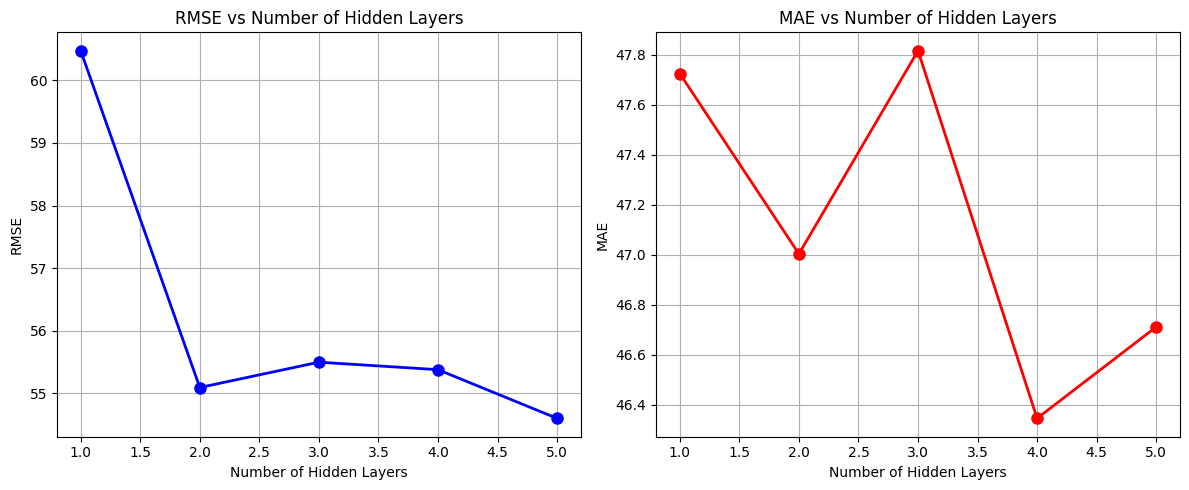

In [3]:
# Question 1: Evaluate MLP with increasing hidden layers (1-5, 50 nodes each)
print("=== QUESTION 1: Hidden Layers Analysis ===")

# Prepare data
data = sm.datasets.sunspots.load_pandas().data
X = np.arange(len(data)).reshape(-1, 1)
y = data['SUNACTIVITY'].values

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_scaled = scaler.fit_transform(y.reshape(-1, 1)).ravel()

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, shuffle=False)

# Test different numbers of hidden layers
hidden_layers_configs = [
    (50,),           # 1 layer
    (50, 50),        # 2 layers
    (50, 50, 50),    # 3 layers
    (50, 50, 50, 50), # 4 layers
    (50, 50, 50, 50, 50) # 5 layers
]

results_q1 = []

for i, hidden_config in enumerate(hidden_layers_configs, 1):
    mlp = MLPRegressor(
        hidden_layer_sizes=hidden_config,
        activation='relu',
        solver='adam',
        max_iter=2000,
        random_state=42
    )
    
    mlp.fit(X_train, y_train)
    y_pred = mlp.predict(X_test)
    
    # Convert back to original scale
    y_pred_original = scaler.inverse_transform(y_pred.reshape(-1, 1)).ravel()
    y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
    
    rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
    mae = mean_absolute_error(y_test_original, y_pred_original)
    
    results_q1.append({
        'layers': i,
        'config': hidden_config,
        'rmse': rmse,
        'mae': mae
    })
    
    print(f"{i} Hidden Layer(s) {hidden_config}: RMSE={rmse:.4f}, MAE={mae:.4f}")

# Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

layers = [r['layers'] for r in results_q1]
rmse_values = [r['rmse'] for r in results_q1]
mae_values = [r['mae'] for r in results_q1]

ax1.plot(layers, rmse_values, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Hidden Layers')
ax1.set_ylabel('RMSE')
ax1.set_title('RMSE vs Number of Hidden Layers')
ax1.grid(True)

ax2.plot(layers, mae_values, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Hidden Layers')
ax2.set_ylabel('MAE')
ax2.set_title('MAE vs Number of Hidden Layers')
ax2.grid(True)

plt.tight_layout()
plt.show()

## Discussion:
ٍٍRMSE dropped fairly after adding more layers, while MAE did not change much and was platueing with more layers. The RMSE is more sensitive to outliers penalising large errors more where it was inferred in in the network with a single hidden layer, while MAE is more concerned with the average absloute errors values mean as a whole. This tells us that the model did not benefit much after adding more than 2 hidden layers, i.e. the model weights were not changing much by more layers.

## Neural Network  Visualisations 

Architecture visualisation using (VisualTorch)

1. **Layered View** - 2D network architecture with layers
2. **Graph View** - Node-based computational graph
3. **LeNet Style** - CNN-style architectural diagram

In [ ]:


print("=== VISUALIZING NEURAL NETWORKS WITH VISUALTORCH ===\n")

# Define PyTorch MLP models matching our sklearn configurations
class MLPModel(nn.Module):
    """Generic MLP model that matches sklearn MLPRegressor architecture"""
    def __init__(self, hidden_layers):
        super(MLPModel, self).__init__()
        layers = []
        
        # Input layer
        input_size = 1
        
        # Hidden layers with ReLU activation
        for hidden_size in hidden_layers:
            layers.append(nn.Linear(input_size, hidden_size))
            layers.append(nn.ReLU())
            input_size = hidden_size
        
        # Output layer
        layers.append(nn.Linear(input_size, 1))
        
        self.model = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.model(x)

# Create models for each configuration from Question 1
hidden_configs = [
    (50,),                    # 1 layer
    (50, 50),                 # 2 layers
    (50, 50, 50),             # 3 layers
    (50, 50, 50, 50),         # 4 layers
    (50, 50, 50, 50, 50)      # 5 layers
]

models = []
for config in hidden_configs:
    model = MLPModel(config)
    models.append((config, model))
    print(f"Created model with hidden layers: {config}")

print(f"\nTotal models created: {len(models)}")
print("Ready for visualization!")

=== VISUALIZING NEURAL NETWORKS WITH VISUALTORCH ===

Created model with hidden layers: (50,)
Created model with hidden layers: (50, 50)
Created model with hidden layers: (50, 50, 50)
Created model with hidden layers: (50, 50, 50, 50)
Created model with hidden layers: (50, 50, 50, 50, 50)

Total models created: 5
Ready for visualization!


### 1. Layered View - 2D Network Architecture


=== LAYERED VIEW VISUALIZATIONS ===

Visualizing 1 Hidden Layer(s): (50,)


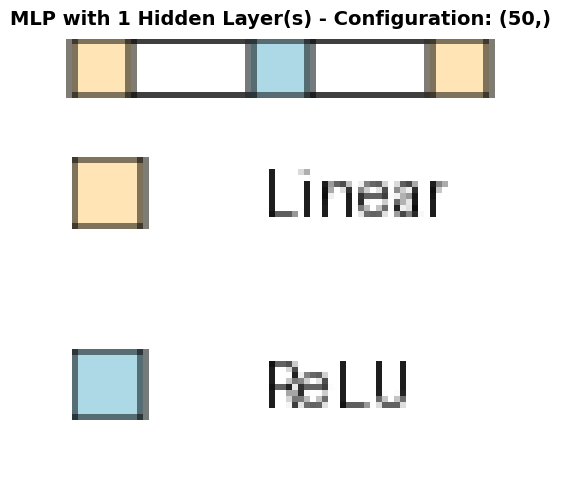

Total layers in model: 4
------------------------------------------------------------
Visualizing 2 Hidden Layer(s): (50, 50)


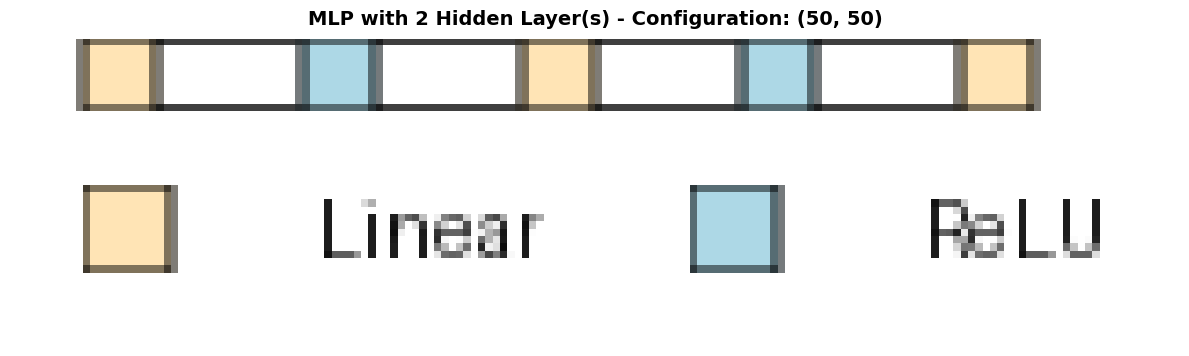

Total layers in model: 6
------------------------------------------------------------
Visualizing 3 Hidden Layer(s): (50, 50, 50)


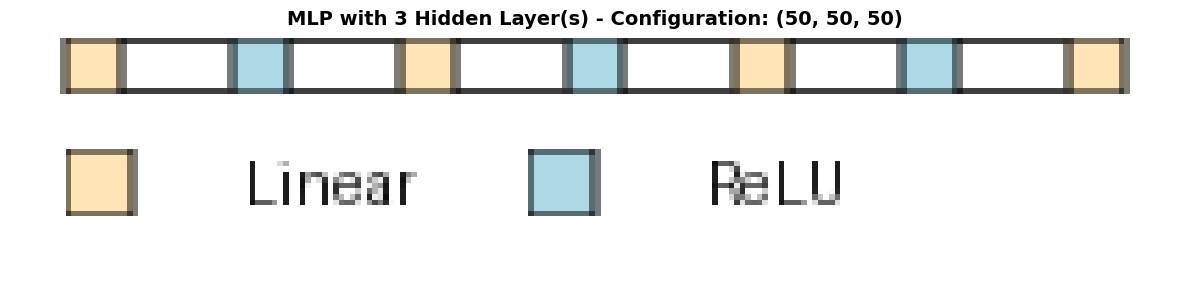

Total layers in model: 8
------------------------------------------------------------
Visualizing 4 Hidden Layer(s): (50, 50, 50, 50)


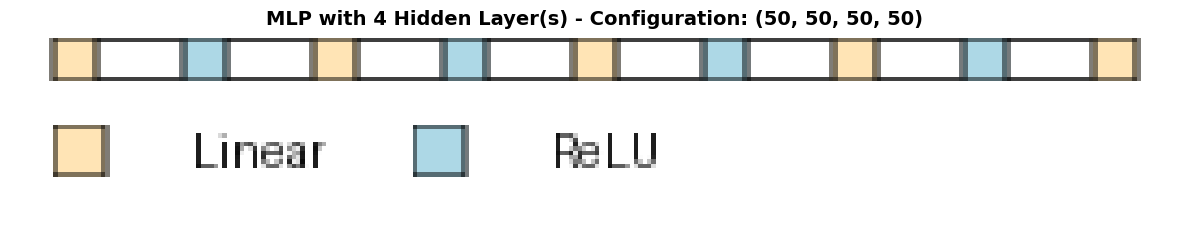

Total layers in model: 10
------------------------------------------------------------
Visualizing 5 Hidden Layer(s): (50, 50, 50, 50, 50)


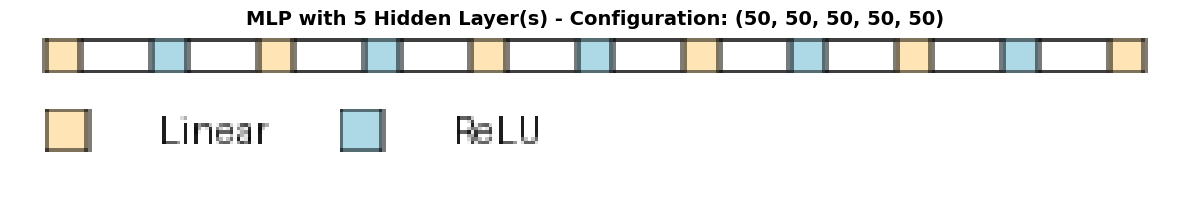

Total layers in model: 12
------------------------------------------------------------


In [ ]:
# LAYERED VIEW - Visualize all configurations
print("=== LAYERED VIEW VISUALIZATIONS ===\n")

for i, (config, model) in enumerate(models, 1):
    print(f"Visualizing {i} Hidden Layer(s): {config}")
    # VisualTorch expects input_shape, not a tensor
    input_shape = (1, 1)  # (batch, features)
    img = layered_view(
        model,
        input_shape=input_shape,
        legend=True,
        min_z=10,
        min_xy=10,
        max_z=100,
        max_xy=400,
        scale_z=0.2,
        scale_xy=1,
        one_dim_orientation='z',
        background_fill='white',
        draw_volume=False,  # 2D box view
        padding=10,
        spacing=20,
        draw_funnel=True,
        shade_step=10,
        font_color='black',
        opacity=255
    )
    plt.figure(figsize=(7, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'MLP with {i} Hidden Layer(s) - Configuration: {config}', fontsize=14, fontweight='bold', pad=10)
    plt.tight_layout()
    plt.show()
    print(f"Total layers in model: {len(list(model.modules())) - 1}")
    print("-" * 60)

### 2. Graph View - Computational Graph



=== GRAPH VIEW VISUALIZATIONS ===

Visualizing Graph for 1 Hidden Layer(s): (50,)


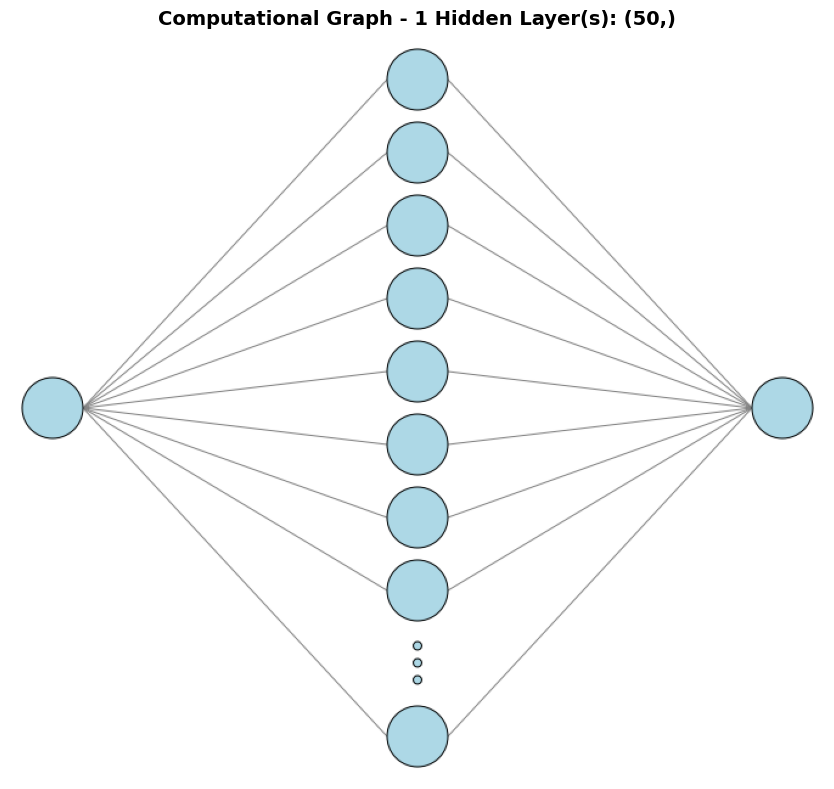

------------------------------------------------------------
Visualizing Graph for 2 Hidden Layer(s): (50, 50)


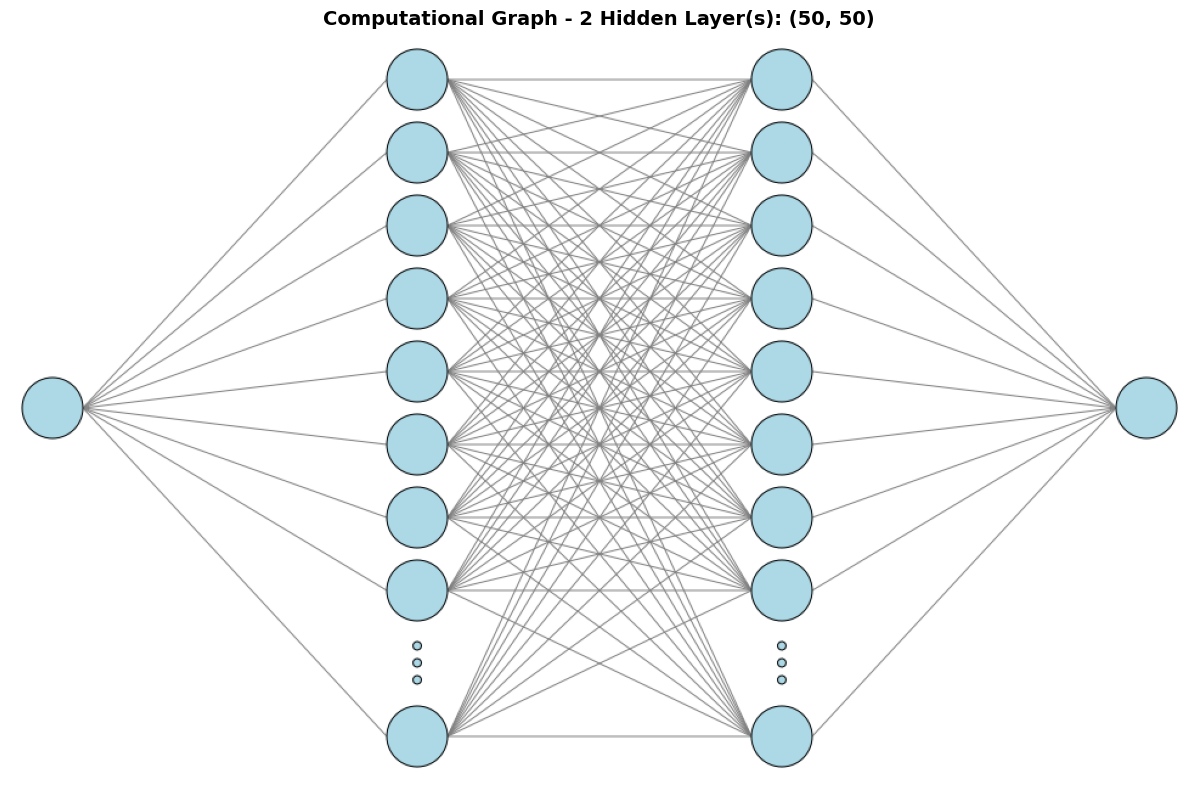

------------------------------------------------------------
Visualizing Graph for 3 Hidden Layer(s): (50, 50, 50)


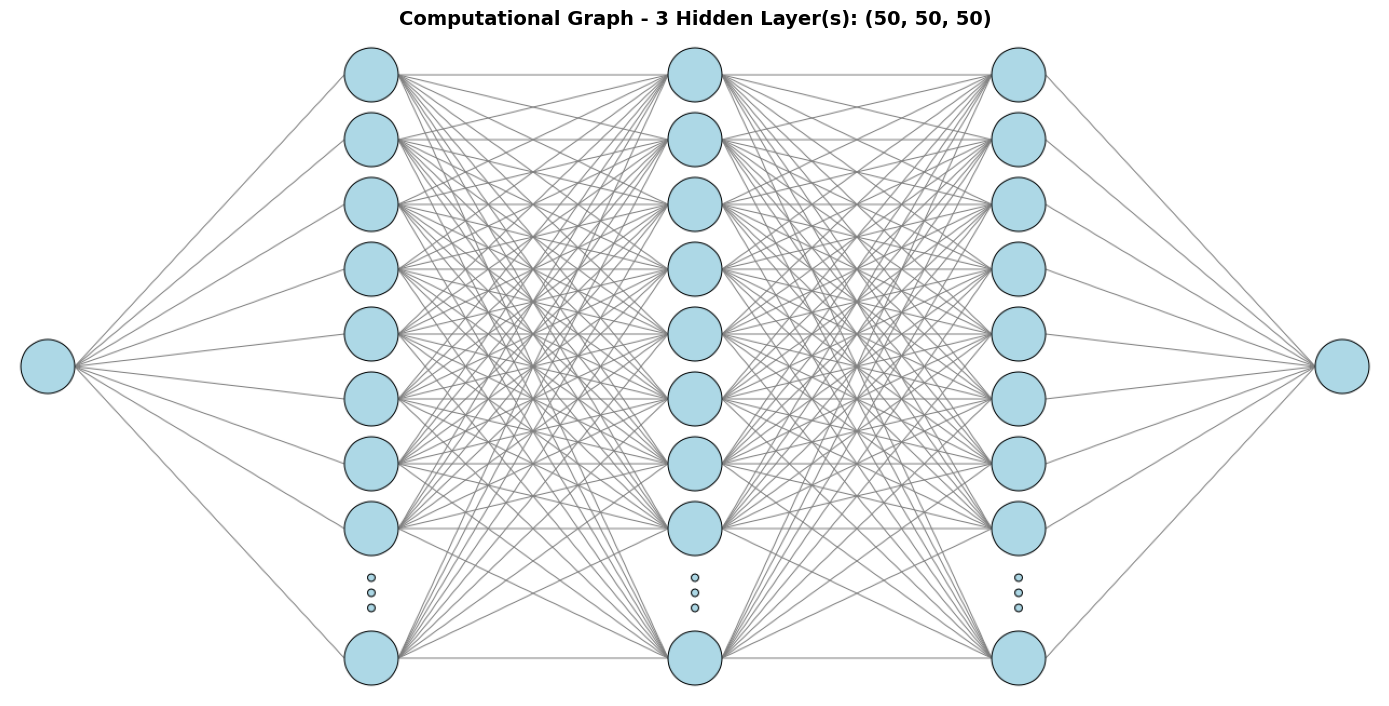

------------------------------------------------------------
Visualizing Graph for 5 Hidden Layer(s): (50, 50, 50, 50, 50)


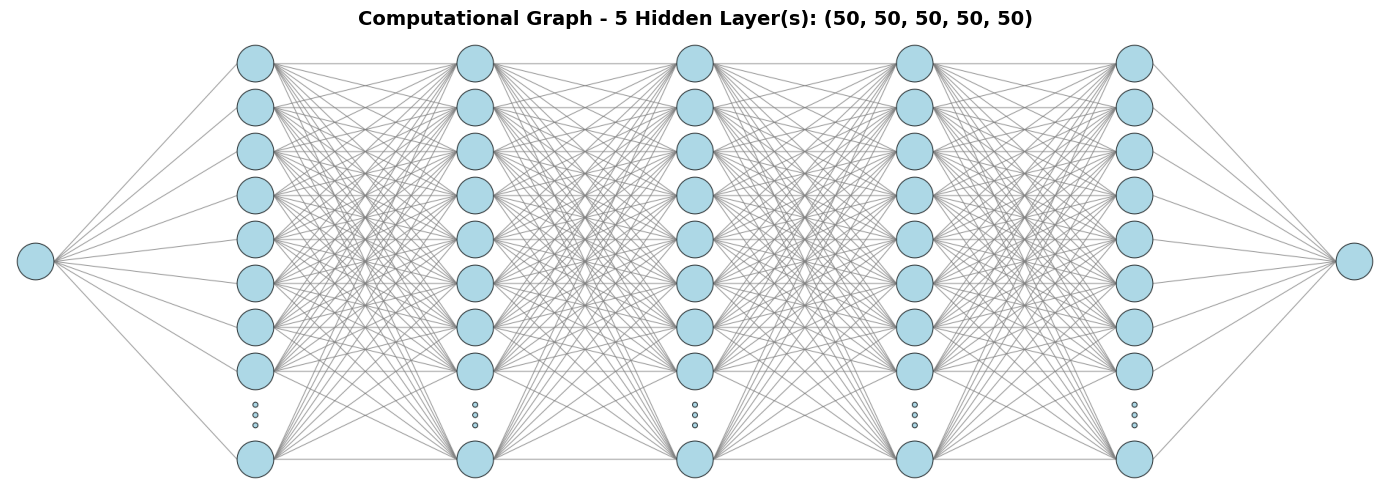

------------------------------------------------------------


In [23]:
# GRAPH VIEW - Computational graph visualization
print("=== GRAPH VIEW VISUALIZATIONS ===\n")

# Visualize selected configurations (1, 2, 3, and 5 layers to avoid too many plots)
selected_indices = [0, 1, 2, 4]  # 1, 2, 3, and 5 hidden layers

for idx in selected_indices:
    config, model = models[idx]
    num_layers = idx + 1
    
    print(f"Visualizing Graph for {num_layers} Hidden Layer(s): {config}")
    
    # VisualTorch graph_view expects input_shape tuple
    input_shape = (1, 1)  # (batch, features)
    
    # Generate graph view
    img = graph_view(
        model,
        input_shape=input_shape,
        node_size=50,
        background_fill='white',
        padding=10,
        layer_spacing=250,
        node_spacing=10,
        connector_fill='gray',
        connector_width=1,
        ellipsize_after=10,
        show_neurons=True,
        opacity=255
    )
    
    # Display the image
    plt.figure(figsize=(14, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'Computational Graph - {num_layers} Hidden Layer(s): {config}', 
              fontsize=14, fontweight='bold', pad=10)
    plt.tight_layout()
    plt.show()
    
    print("-" * 60)

### 3. LeNet Style - CNN-Style Architecture Diagram

Shows the network in a style similar to CNN architecture diagrams, displaying layer dimensions and connections.

=== LENET STYLE VISUALIZATIONS ===

Visualizing LeNet Style for 1 Hidden Layer(s): (50,)


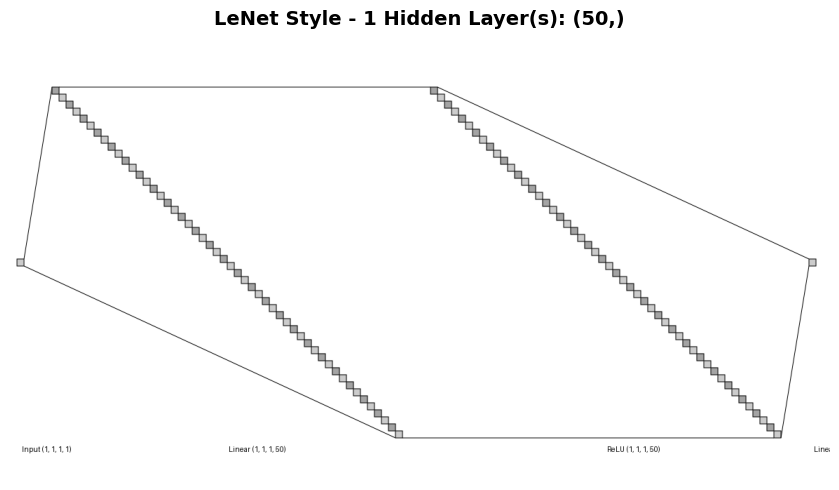

Architecture breakdown:
  Input: 1 feature
  Hidden Layer 1: 50 nodes (ReLU activation)
  Output: 1 prediction
------------------------------------------------------------
Visualizing LeNet Style for 2 Hidden Layer(s): (50, 50)


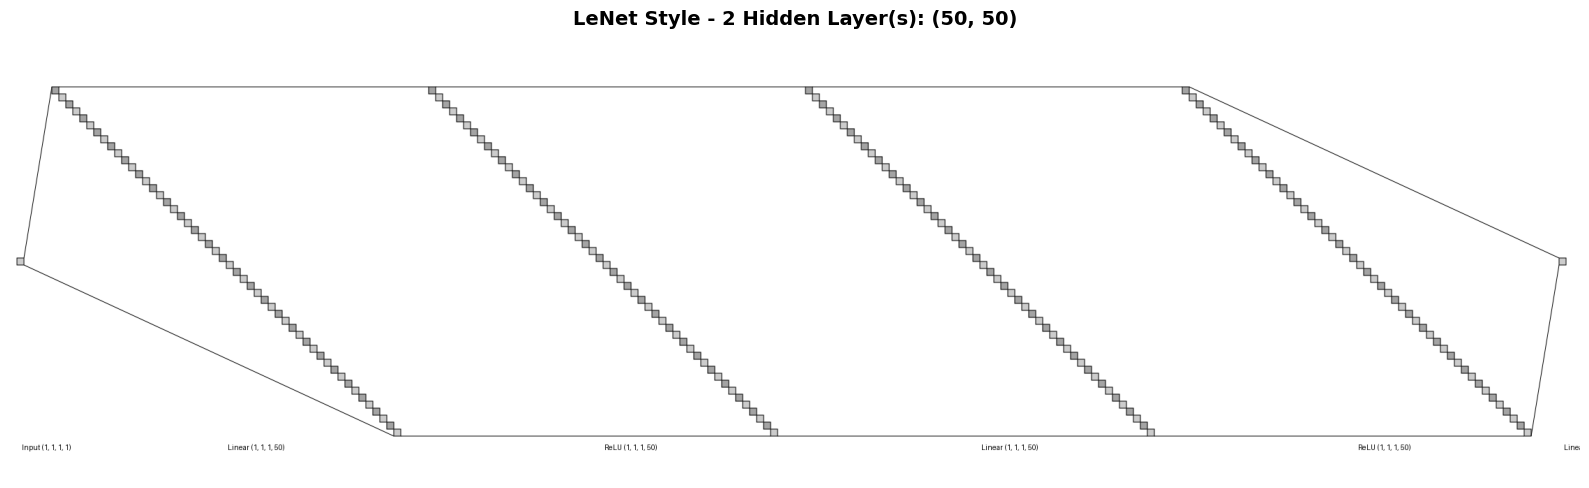

Architecture breakdown:
  Input: 1 feature
  Hidden Layer 1: 50 nodes (ReLU activation)
  Hidden Layer 2: 50 nodes (ReLU activation)
  Output: 1 prediction
------------------------------------------------------------
Visualizing LeNet Style for 3 Hidden Layer(s): (50, 50, 50)


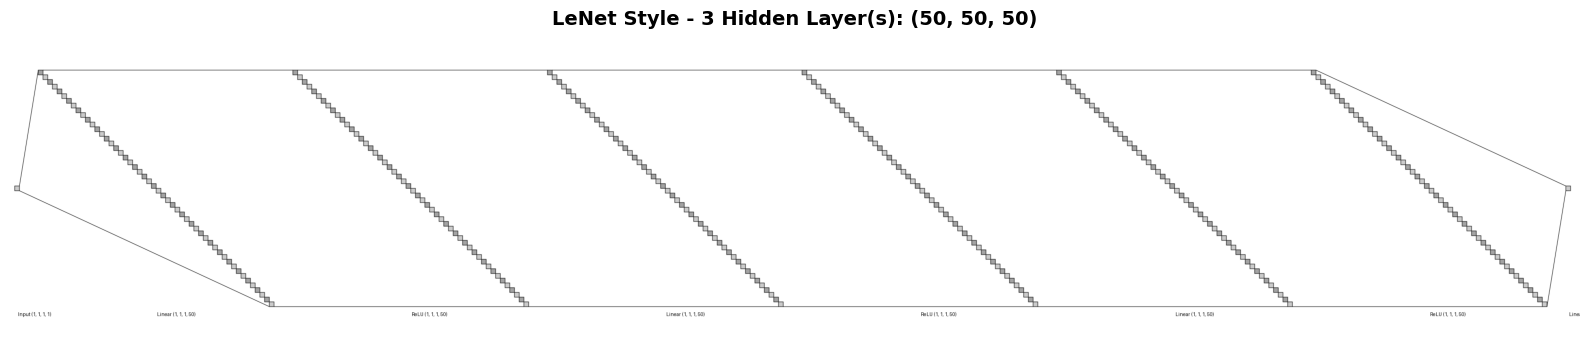

Architecture breakdown:
  Input: 1 feature
  Hidden Layer 1: 50 nodes (ReLU activation)
  Hidden Layer 2: 50 nodes (ReLU activation)
  Hidden Layer 3: 50 nodes (ReLU activation)
  Output: 1 prediction
------------------------------------------------------------
Visualizing LeNet Style for 5 Hidden Layer(s): (50, 50, 50, 50, 50)


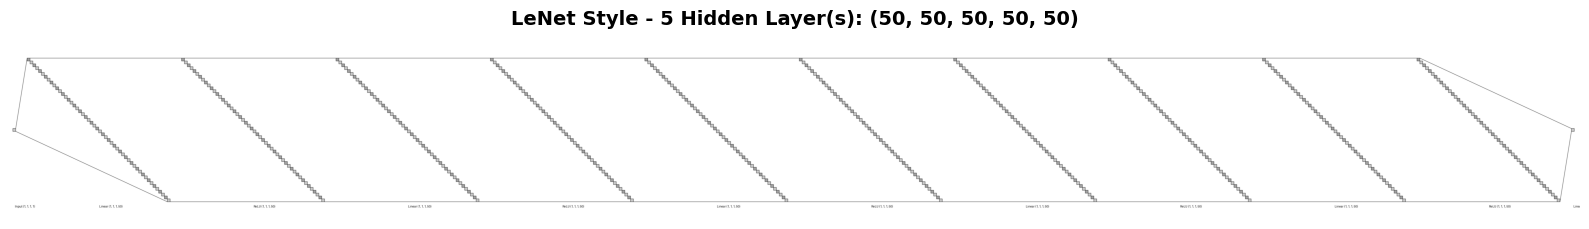

Architecture breakdown:
  Input: 1 feature
  Hidden Layer 1: 50 nodes (ReLU activation)
  Hidden Layer 2: 50 nodes (ReLU activation)
  Hidden Layer 3: 50 nodes (ReLU activation)
  Hidden Layer 4: 50 nodes (ReLU activation)
  Hidden Layer 5: 50 nodes (ReLU activation)
  Output: 1 prediction
------------------------------------------------------------


In [24]:
# LENET STYLE VIEW - CNN-style architecture visualization
print("=== LENET STYLE VISUALIZATIONS ===\n")

# Visualize selected configurations
for idx in selected_indices:
    config, model = models[idx]
    num_layers = idx + 1
    
    print(f"Visualizing LeNet Style for {num_layers} Hidden Layer(s): {config}")
    
    # VisualTorch lenet_view expects input_shape tuple
    input_shape = (1, 1)  # (batch, features)
    
    # Generate LeNet-style view
    img = lenet_view(
        model,
        input_shape=input_shape,
        min_z=1,
        min_xy=10,
        max_xy=2000,
        scale_z=1,
        scale_xy=1,
        one_dim_orientation='z',
        background_fill='white',
        padding=10,
        spacing=30,
        draw_funnel=True,
        shade_step=10,
        font_color='black',
        opacity=255,
        max_channels=100,
        offset_z=10
    )
    
    # Display the image
    plt.figure(figsize=(16, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'LeNet Style - {num_layers} Hidden Layer(s): {config}', 
              fontsize=14, fontweight='bold', pad=10)
    plt.tight_layout()
    plt.show()
    
    # Print architecture details
    print(f"Architecture breakdown:")
    print(f"  Input: 1 feature")
    for i, h in enumerate(config, 1):
        print(f"  Hidden Layer {i}: {h} nodes (ReLU activation)")
    print(f"  Output: 1 prediction")
    print("-" * 60)

### Architecture Comparison Summary


=== COMPREHENSIVE VISUALIZATION: 3 Hidden Layer Model ===

Model Configuration: (50, 50, 50)
Total Parameters: 5251

Generating Layered View...
Generating Graph View...
Generating LeNet Style View...


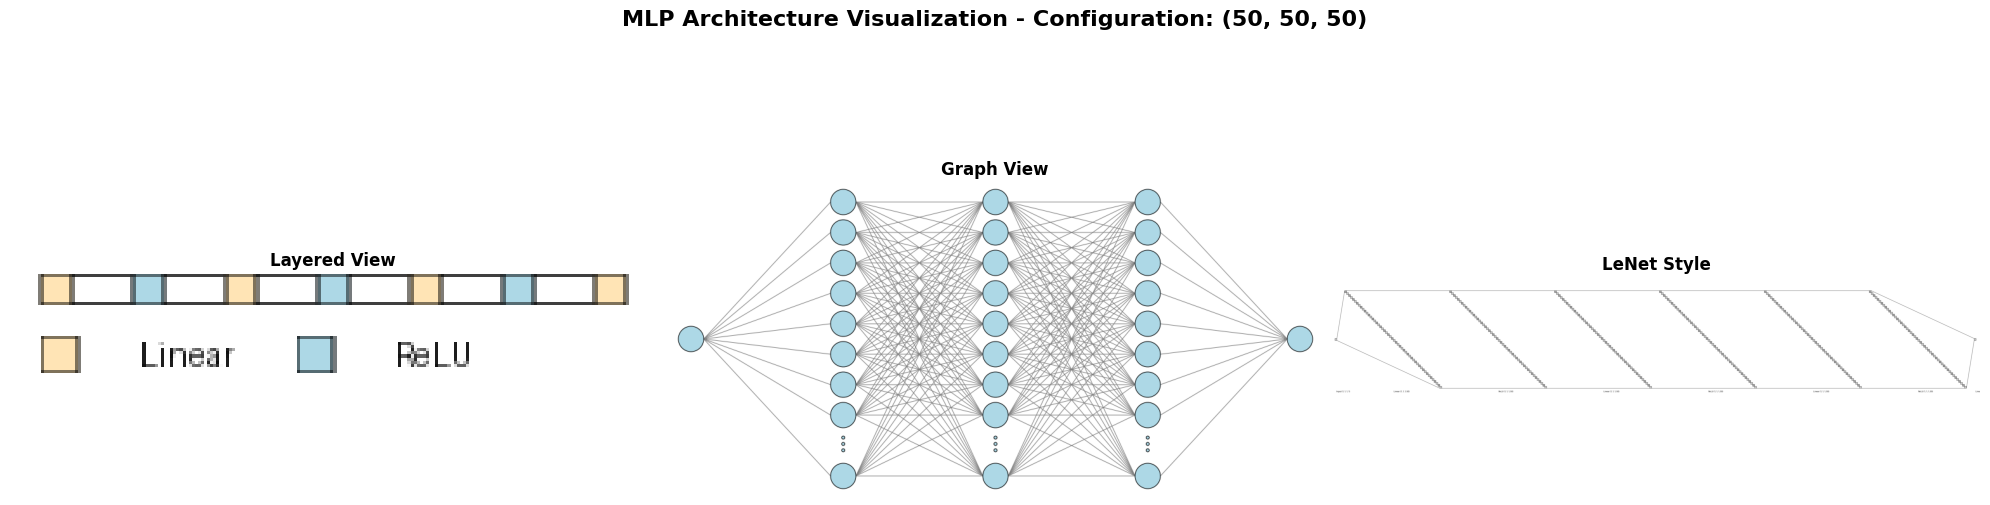


✓ All visualizations complete!

Model Summary:
  • Input features: 1
  • Hidden layers: 3 (50, 50, 50 nodes)
  • Output: 1 prediction
  • Activation: ReLU
  • Total trainable parameters: 5251


In [25]:
# ALL THREE VIEWS SIDE-BY-SIDE for a specific model
print("=== COMPREHENSIVE VISUALIZATION: 3 Hidden Layer Model ===\n")

# Use the 3-layer model (index 2)
config, model = models[2]  # (50, 50, 50)
input_shape = (1, 1)  # VisualTorch uses shape tuple

print(f"Model Configuration: {config}")
print(f"Total Parameters: {sum(p.numel() for p in model.parameters())}")

# Create figure with 3 subplots
fig = plt.figure(figsize=(20, 6))

# 1. Layered View
print("\nGenerating Layered View...")
img_layered = layered_view(
    model,
    input_shape=input_shape,
    legend=True,
    min_z=10,
    min_xy=10,
    max_z=80,
    max_xy=300,
    scale_z=0.2,
    scale_xy=1,
    one_dim_orientation='z',
    background_fill='white',
    draw_volume=False,
    padding=10,
    spacing=20,
    draw_funnel=True,
    shade_step=10,
    font_color='black',
    opacity=255
)

ax1 = plt.subplot(1, 3, 1)
ax1.imshow(img_layered)
ax1.axis('off')
ax1.set_title('Layered View', fontsize=12, fontweight='bold')

# 2. Graph View
print("Generating Graph View...")
img_graph = graph_view(
    model,
    input_shape=input_shape,
    node_size=40,
    background_fill='white',
    padding=10,
    layer_spacing=200,
    node_spacing=8,
    connector_fill='gray',
    connector_width=1,
    ellipsize_after=10,
    show_neurons=True,
    opacity=255
)

ax2 = plt.subplot(1, 3, 2)
ax2.imshow(img_graph)
ax2.axis('off')
ax2.set_title('Graph View', fontsize=12, fontweight='bold')

# 3. LeNet Style
print("Generating LeNet Style View...")
img_lenet = lenet_view(
    model,
    input_shape=input_shape,
    min_z=1,
    min_xy=10,
    max_xy=1500,
    scale_z=1,
    scale_xy=1,
    one_dim_orientation='z',
    background_fill='white',
    padding=10,
    spacing=30,
    draw_funnel=True,
    shade_step=10,
    font_color='black',
    opacity=255,
    max_channels=100,
    offset_z=10
)

ax3 = plt.subplot(1, 3, 3)
ax3.imshow(img_lenet)
ax3.axis('off')
ax3.set_title('LeNet Style', fontsize=12, fontweight='bold')

plt.suptitle(f'MLP Architecture Visualization - Configuration: {config}', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n✓ All visualizations complete!")
print(f"\nModel Summary:")
print(f"  • Input features: 1")
print(f"  • Hidden layers: 3 (50, 50, 50 nodes)")
print(f"  • Output: 1 prediction")
print(f"  • Activation: ReLU")
print(f"  • Total trainable parameters: {sum(p.numel() for p in model.parameters())}")

# Question 2

*Using scikit-learn fit a 2 hidden layer MLP to the sunspot data using ReLU activation function and the adam solver. Evaluate the change
in RMSE and MAE as the number of nodes in each layer is increased from 10 to 300. Plot and discuss the results.*


=== QUESTION 2: Nodes per Layer Analysis ===
Nodes per layer: 10: RMSE=61.2285, MAE=48.0596
Nodes per layer: 25: RMSE=58.5600, MAE=47.1095
Nodes per layer: 50: RMSE=55.0935, MAE=47.0032
Nodes per layer: 100: RMSE=55.6707, MAE=47.1115
Nodes per layer: 150: RMSE=54.7619, MAE=46.7713
Nodes per layer: 100: RMSE=55.6707, MAE=47.1115
Nodes per layer: 150: RMSE=54.7619, MAE=46.7713
Nodes per layer: 200: RMSE=55.0996, MAE=47.2269
Nodes per layer: 200: RMSE=55.0996, MAE=47.2269
Nodes per layer: 250: RMSE=55.2403, MAE=47.9184
Nodes per layer: 250: RMSE=55.2403, MAE=47.9184
Nodes per layer: 300: RMSE=54.2627, MAE=47.0114
Nodes per layer: 300: RMSE=54.2627, MAE=47.0114


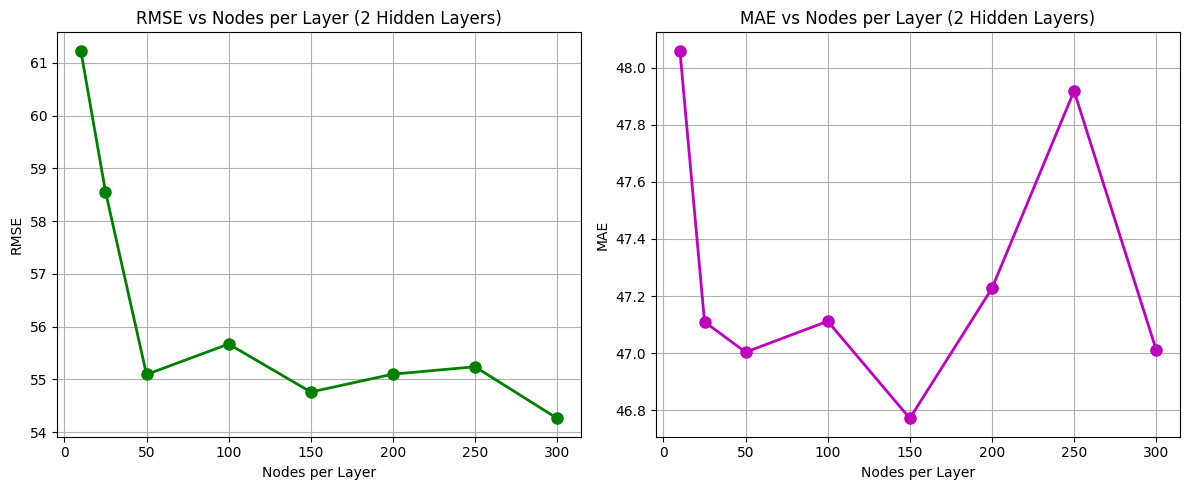

In [27]:
# Question 2: Evaluate 2-layer MLP with varying nodes (10-300)
print("\n=== QUESTION 2: Nodes per Layer Analysis ===")

node_counts = [10, 25, 50, 100, 150, 200, 250, 300]
results_q2 = []

for nodes in node_counts:
    mlp = MLPRegressor(
        hidden_layer_sizes=(nodes, nodes),  # 2 layers with same number of nodes
        activation='relu',
        solver='adam',
        max_iter=2000,
        random_state=42
    )
    
    mlp.fit(X_train, y_train)
    y_pred = mlp.predict(X_test)
    
    # Convert back to original scale
    y_pred_original = scaler.inverse_transform(y_pred.reshape(-1, 1)).ravel()
    y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
    
    rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
    mae = mean_absolute_error(y_test_original, y_pred_original)
    
    results_q2.append({
        'nodes': nodes,
        'rmse': rmse,
        'mae': mae
    })
    
    print(f"Nodes per layer: {nodes}: RMSE={rmse:.4f}, MAE={mae:.4f}")

# Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

nodes = [r['nodes'] for r in results_q2]
rmse_values = [r['rmse'] for r in results_q2]
mae_values = [r['mae'] for r in results_q2]

ax1.plot(nodes, rmse_values, 'go-', linewidth=2, markersize=8)
ax1.set_xlabel('Nodes per Layer')
ax1.set_ylabel('RMSE')
ax1.set_title('RMSE vs Nodes per Layer (2 Hidden Layers)')
ax1.grid(True)

ax2.plot(nodes, mae_values, 'mo-', linewidth=2, markersize=8)
ax2.set_xlabel('Nodes per Layer')
ax2.set_ylabel('MAE')
ax2.set_title('MAE vs Nodes per Layer (2 Hidden Layers)')
ax2.grid(True)

plt.tight_layout()
plt.show()

## Discussion

Similar notion and result pattern applies to this case as in the previous Question 1 results, Both RMSE and MAE indicate good improvment as neurons were increased from 10 to 50, indicating that the model was able to capture more and enough predictor attributes to generalise. An interesting observation in the MAE plot is when neurons were around 200-250 that had spike increase in error, this could be to stochastic variance as the model got more complex. Both RMSE and MAE however indicate that throwing more neurons in the model after the 50 threshold does, i.e. making more complex, does not help in making the model converge better. 

=== QUESTION 2: ARCHITECTURE VISUALIZATIONS ===

Visualizing 2-layer MLP with 10 nodes per layer


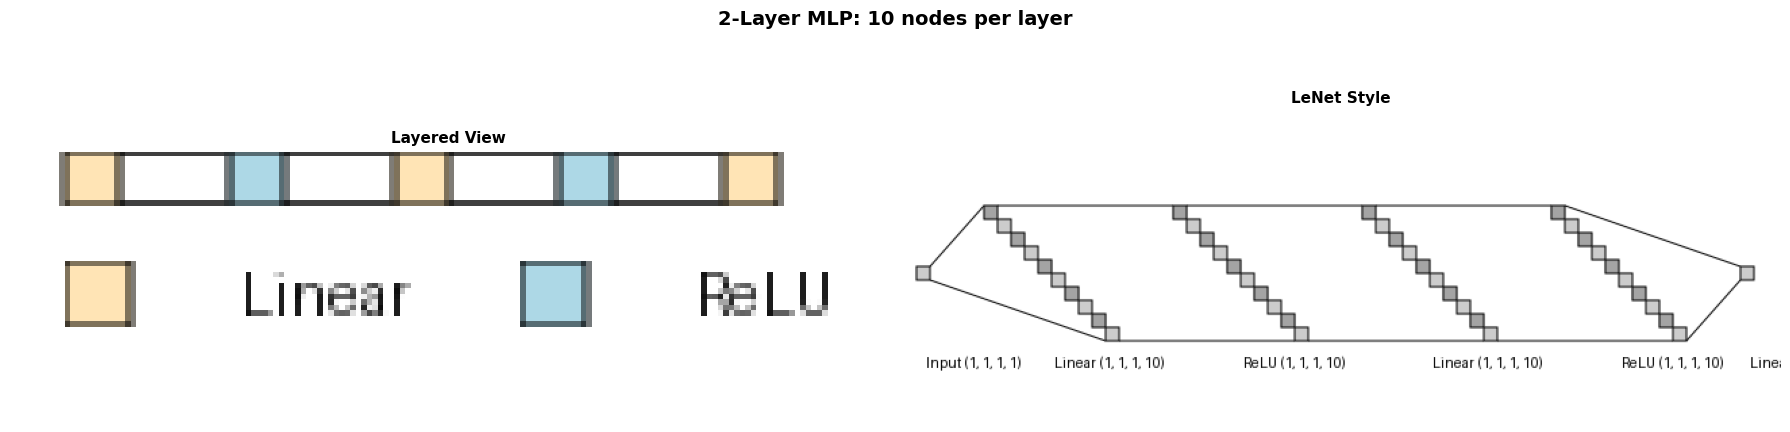

Total parameters: 141
----------------------------------------------------------------------
Visualizing 2-layer MLP with 50 nodes per layer


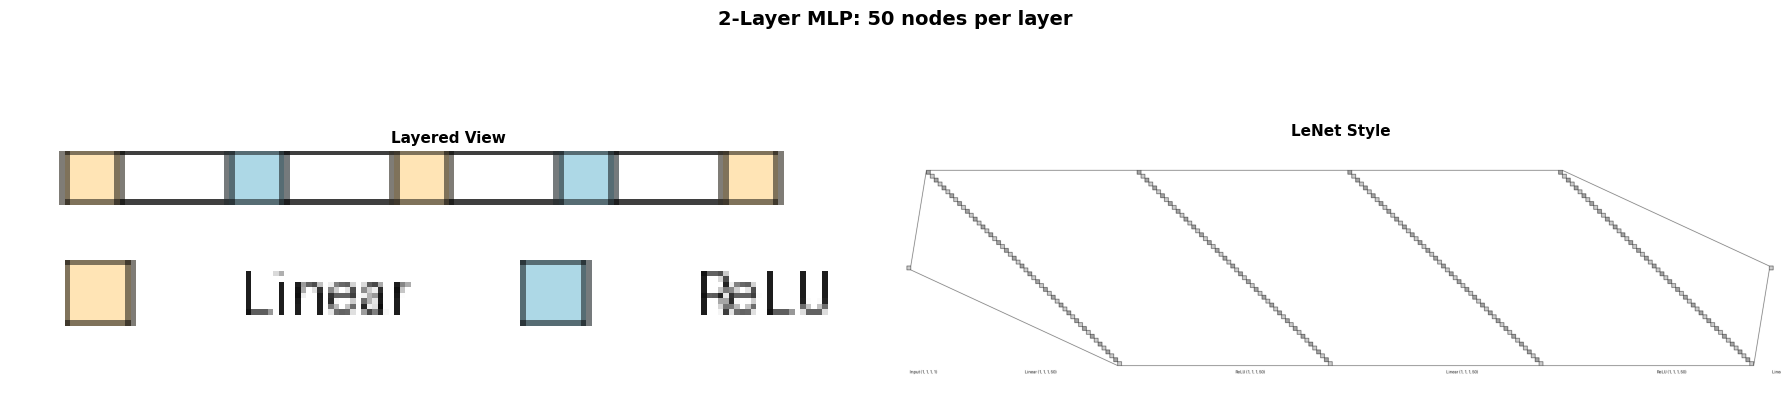

Total parameters: 2701
----------------------------------------------------------------------
Visualizing 2-layer MLP with 150 nodes per layer


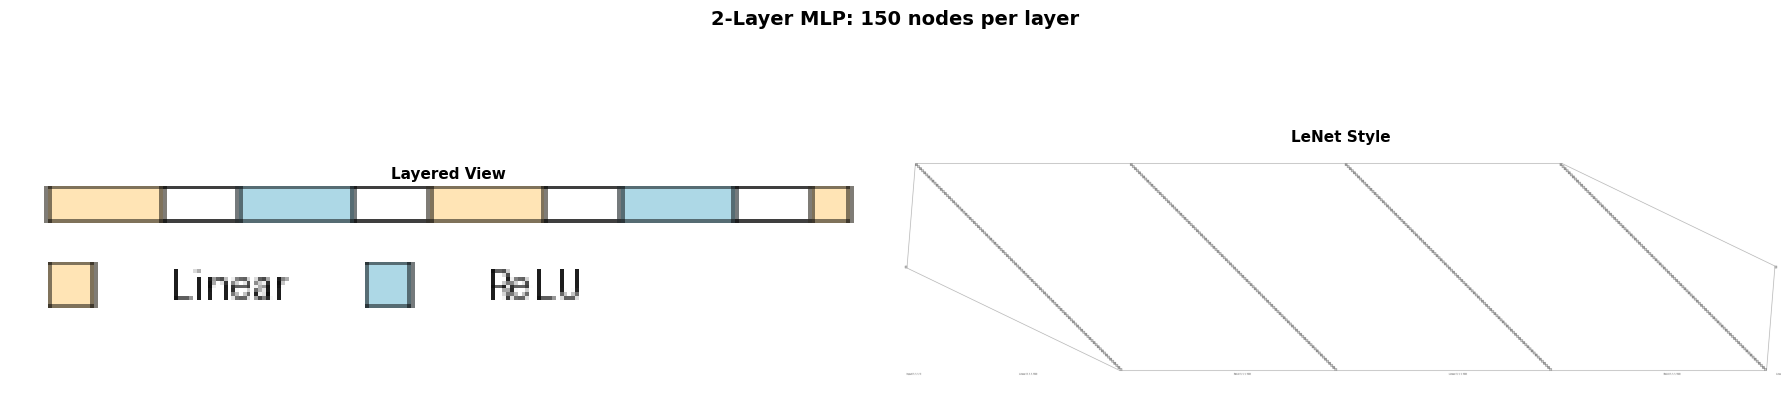

Total parameters: 23101
----------------------------------------------------------------------
Visualizing 2-layer MLP with 300 nodes per layer


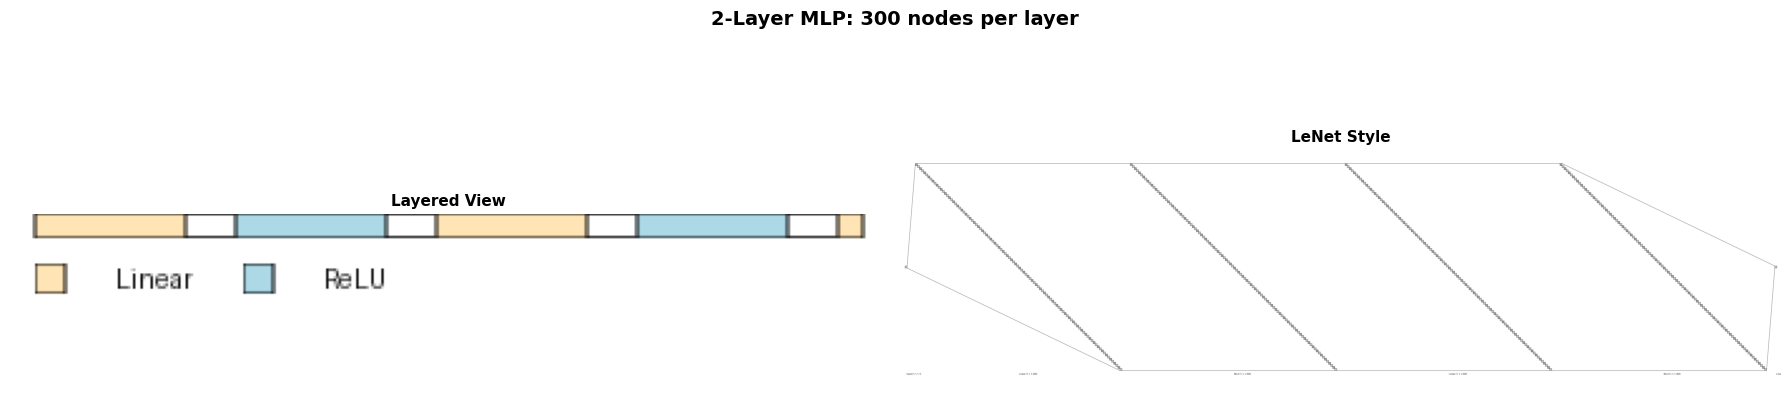

Total parameters: 91201
----------------------------------------------------------------------


In [36]:
# Visualize Question 2 architectures - 2 hidden layers with different node counts
print("=== QUESTION 2: ARCHITECTURE VISUALIZATIONS ===\n")

# Select a few representative configurations
q2_configs = [(10, 10), (50, 50), (150, 150), (300, 300)]

for config in q2_configs:
    print(f"Visualizing 2-layer MLP with {config[0]} nodes per layer")
    
    # Create PyTorch model
    class Q2_MLP(nn.Module):
        def __init__(self, nodes):
            super(Q2_MLP, self).__init__()
            self.model = nn.Sequential(
                nn.Linear(1, nodes),
                nn.ReLU(),
                nn.Linear(nodes, nodes),
                nn.ReLU(),
                nn.Linear(nodes, 1)
            )
        
        def forward(self, x):
            return self.model(x)
    
    model_q2 = Q2_MLP(config[0])
    input_shape = (1, 1)
    
    # Create combined visualization
    fig = plt.figure(figsize=(18, 5))
    
    # Layered View
    img_layered = layered_view(
        model_q2,
        input_shape=input_shape,
        legend=True,
        min_z=10,
        min_xy=10,
        max_z=100,
        max_xy=400,
        scale_z=0.2,
        scale_xy=1,
        one_dim_orientation='z',
        background_fill='white',
        draw_volume=False,
        padding=10,
        spacing=20,
        draw_funnel=True,
        opacity=255
    )
    
    ax1 = plt.subplot(1, 2, 1)
    ax1.imshow(img_layered)
    ax1.axis('off')
    ax1.set_title('Layered View', fontsize=11, fontweight='bold')
    
    # LeNet Style
    img_lenet = lenet_view(
        model_q2,
        input_shape=input_shape,
        min_z=1,
        min_xy=10,
        max_xy=1500,
        scale_z=1,
        scale_xy=1,
        one_dim_orientation='z',
        background_fill='white',
        padding=10,
        spacing=30,
        draw_funnel=True,
        opacity=255,
        max_channels=100,
        offset_z=10
    )
    
    ax2 = plt.subplot(1, 2, 2)
    ax2.imshow(img_lenet)
    ax2.axis('off')
    ax2.set_title('LeNet Style', fontsize=11, fontweight='bold')
    
    plt.suptitle(f'2-Layer MLP: {config[0]} nodes per layer', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f"Total parameters: {sum(p.numel() for p in model_q2.parameters())}")
    print("-" * 70)

# Question 3

*Using scikit-learn fit a 3 hidden layer MLP (50 hidden nodes per layer) to the sunspot data using ReLU activation function and the adam
solver. Evaluate the change in RMSE and MAE using at least 3 different activation functions. Plot and discuss the results.*


=== QUESTION 3: Activation Functions Comparison ===
Activation 'relu': RMSE=55.4981, MAE=47.8156, R²=-0.1053
Activation 'tanh': RMSE=58.5086, MAE=47.1003, R²=-0.2285
Activation 'logistic': RMSE=61.1675, MAE=48.0205, R²=-0.3427


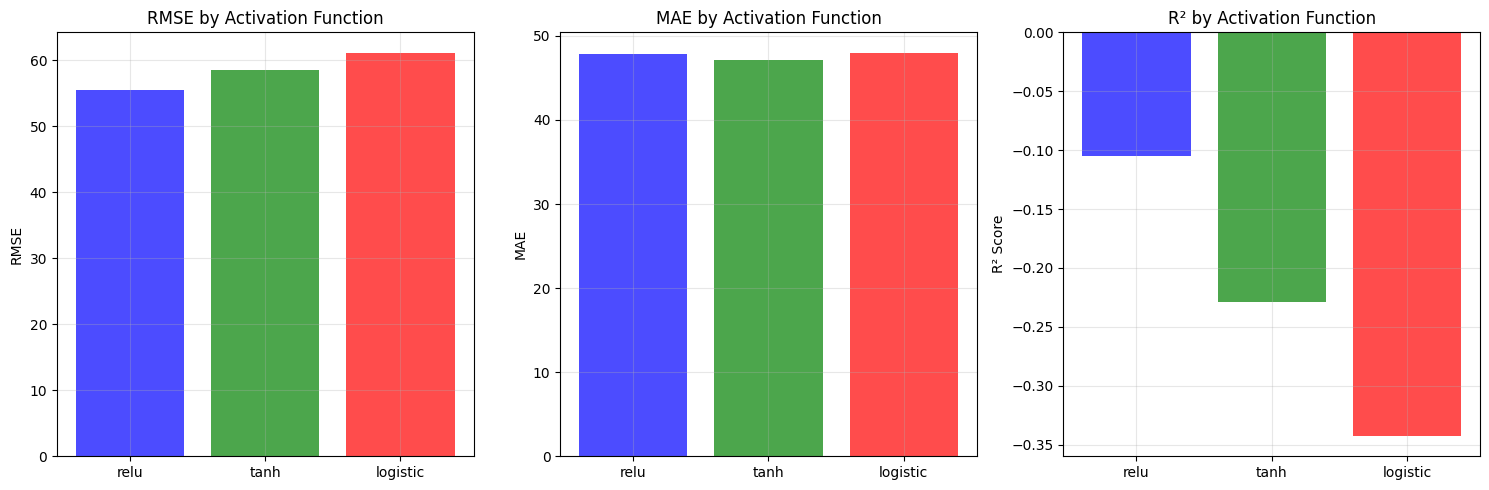

In [37]:
# Question 3: Compare activation functions on 3-layer MLP (50 nodes each)
print("\n=== QUESTION 3: Activation Functions Comparison ===")

activation_functions = ['relu', 'tanh', 'logistic']
results_q3 = []

for activation in activation_functions:
    mlp = MLPRegressor(
        hidden_layer_sizes=(50, 50, 50),  # 3 layers with 50 nodes each
        activation=activation,
        solver='adam',
        max_iter=2000,
        random_state=42
    )
    
    mlp.fit(X_train, y_train)
    y_pred = mlp.predict(X_test)
    
    # Convert back to original scale
    y_pred_original = scaler.inverse_transform(y_pred.reshape(-1, 1)).ravel()
    y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
    
    rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
    mae = mean_absolute_error(y_test_original, y_pred_original)
    r2 = r2_score(y_test_original, y_pred_original)
    
    results_q3.append({
        'activation': activation,
        'rmse': rmse,
        'mae': mae,
        'r2': r2
    })
    
    print(f"Activation '{activation}': RMSE={rmse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")

# Plot results
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

activations = [r['activation'] for r in results_q3]
rmse_values = [r['rmse'] for r in results_q3]
mae_values = [r['mae'] for r in results_q3]
r2_values = [r['r2'] for r in results_q3]

ax1.bar(activations, rmse_values, color=['blue', 'green', 'red'], alpha=0.7)
ax1.set_ylabel('RMSE')
ax1.set_title('RMSE by Activation Function')
ax1.grid(True, alpha=0.3)

ax2.bar(activations, mae_values, color=['blue', 'green', 'red'], alpha=0.7)
ax2.set_ylabel('MAE')
ax2.set_title('MAE by Activation Function')
ax2.grid(True, alpha=0.3)

ax3.bar(activations, r2_values, color=['blue', 'green', 'red'], alpha=0.7)
ax3.set_ylabel('R² Score')
ax3.set_title('R² by Activation Function')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Discussion
 All models preformed relatively poor in terms of RMSE, MAE, and R^2. Logistic regression preformed the worse overall, indicated by the very low negative R^2 value, which this could be attributed to vanishing gradient problem that Sigmoid function are known to suffer, as the network propogates and backpropgates in each layer the gradient gets smaller and consquently updating the weights and biases drops signficantly.
The most sensitive measure RMSE showed ReLU was slighly better than Tanh, and Tanh was slighty better the Sigmoid logistic activation function, indicating ReLU was a better at. As for MAE, the metric captured all similar values suggesting mean value of the weights did not differ much across the three atcivition functions. As for R^2, all functions scored negatively suggesting the model is doing worse than random choice, however ReLU was the least bad, much better than Tanh and the Sigmoid, this could be do to the fact that the function handles the vanishing gradient problem much better, as it converts negative inputs to 0 and positive inputs as originaly they are, linearly. 

## Neural Network Visualization

Visualizing the 3-layer MLP architecture with different activation functions.

=== QUESTION 3: ARCHITECTURE VISUALIZATIONS ===

Visualizing 3-layer MLP with 'relu' activation


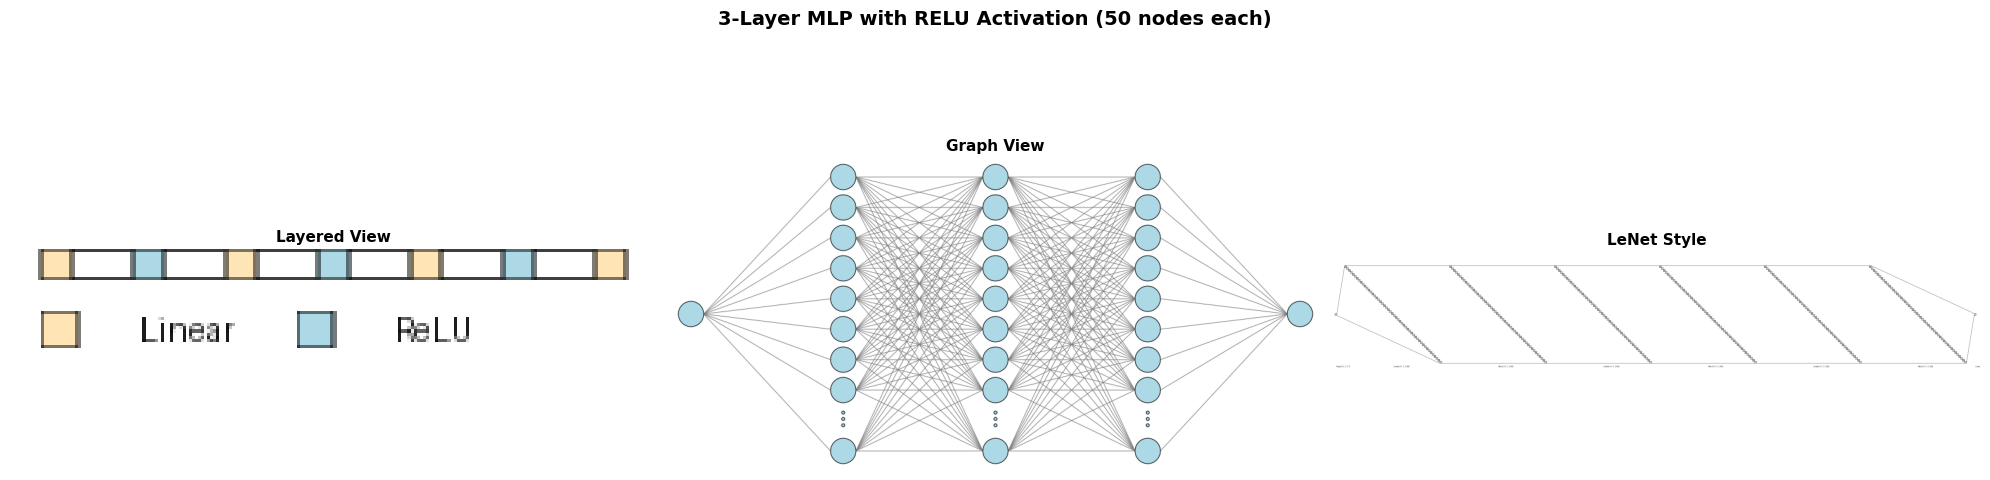

Total parameters: 5251
Activation function: relu
----------------------------------------------------------------------
Visualizing 3-layer MLP with 'tanh' activation


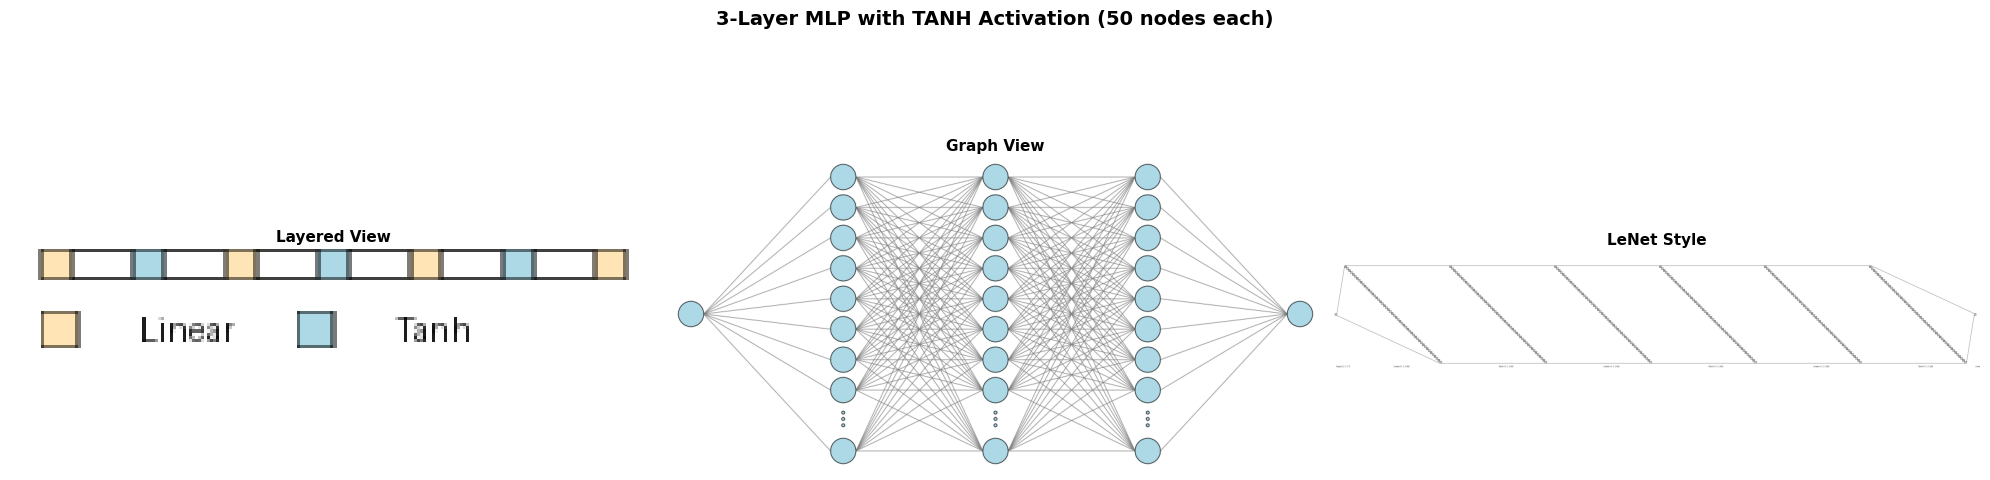

Total parameters: 5251
Activation function: tanh
----------------------------------------------------------------------
Visualizing 3-layer MLP with 'logistic' activation


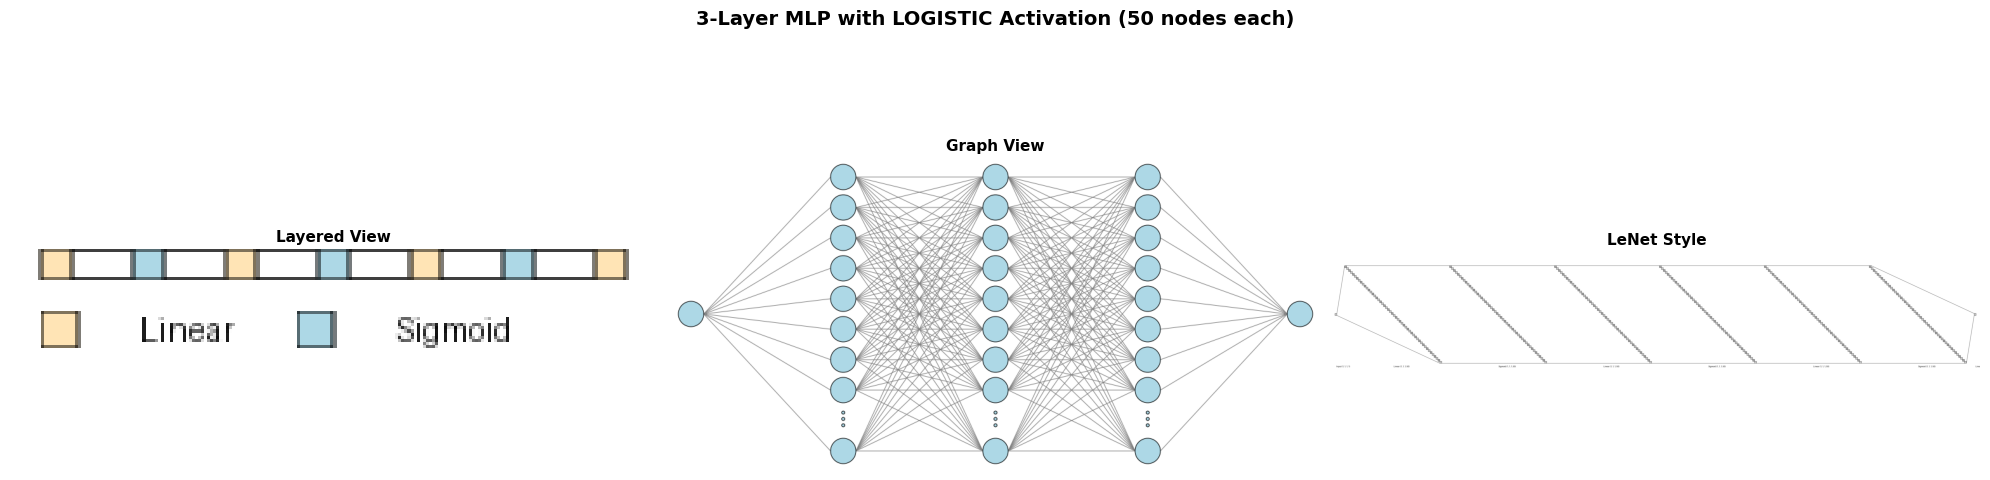

Total parameters: 5251
Activation function: logistic
----------------------------------------------------------------------


In [38]:
# Visualize Question 3 architectures - 3 hidden layers with different activations
print("=== QUESTION 3: ARCHITECTURE VISUALIZATIONS ===\n")

# Define activation functions to visualize
activations_to_viz = ['relu', 'tanh', 'logistic']
activation_modules = {
    'relu': nn.ReLU,
    'tanh': nn.Tanh,
    'logistic': nn.Sigmoid
}

for activation_name in activations_to_viz:
    print(f"Visualizing 3-layer MLP with '{activation_name}' activation")
    
    # Create PyTorch model with specific activation
    class Q3_MLP(nn.Module):
        def __init__(self, activation_fn):
            super(Q3_MLP, self).__init__()
            self.model = nn.Sequential(
                nn.Linear(1, 50),
                activation_fn(),
                nn.Linear(50, 50),
                activation_fn(),
                nn.Linear(50, 50),
                activation_fn(),
                nn.Linear(50, 1)
            )
        
        def forward(self, x):
            return self.model(x)
    
    model_q3 = Q3_MLP(activation_modules[activation_name])
    input_shape = (1, 1)
    
    # Create three-panel visualization
    fig = plt.figure(figsize=(20, 6))
    
    # 1. Layered View
    img_layered = layered_view(
        model_q3,
        input_shape=input_shape,
        legend=True,
        min_z=10,
        min_xy=10,
        max_z=80,
        max_xy=300,
        scale_z=0.2,
        scale_xy=1,
        one_dim_orientation='z',
        background_fill='white',
        draw_volume=False,
        padding=10,
        spacing=20,
        draw_funnel=True,
        opacity=255
    )
    
    ax1 = plt.subplot(1, 3, 1)
    ax1.imshow(img_layered)
    ax1.axis('off')
    ax1.set_title('Layered View', fontsize=11, fontweight='bold')
    
    # 2. Graph View
    img_graph = graph_view(
        model_q3,
        input_shape=input_shape,
        node_size=40,
        background_fill='white',
        padding=10,
        layer_spacing=200,
        node_spacing=8,
        connector_fill='gray',
        connector_width=1,
        ellipsize_after=10,
        show_neurons=True,
        opacity=255
    )
    
    ax2 = plt.subplot(1, 3, 2)
    ax2.imshow(img_graph)
    ax2.axis('off')
    ax2.set_title('Graph View', fontsize=11, fontweight='bold')
    
    # 3. LeNet Style
    img_lenet = lenet_view(
        model_q3,
        input_shape=input_shape,
        min_z=1,
        min_xy=10,
        max_xy=1500,
        scale_z=1,
        scale_xy=1,
        one_dim_orientation='z',
        background_fill='white',
        padding=10,
        spacing=30,
        draw_funnel=True,
        opacity=255,
        max_channels=100,
        offset_z=10
    )
    
    ax3 = plt.subplot(1, 3, 3)
    ax3.imshow(img_lenet)
    ax3.axis('off')
    ax3.set_title('LeNet Style', fontsize=11, fontweight='bold')
    
    plt.suptitle(f'3-Layer MLP with {activation_name.upper()} Activation (50 nodes each)', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f"Total parameters: {sum(p.numel() for p in model_q3.parameters())}")
    print(f"Activation function: {activation_name}")
    print("-" * 70)

# Question 4
*Using scikit-learn fit a 2 hidden layer MLP (50 hidden nodes per layer) to the sunspot data using ReLU activation function and the adam
solver. Perform Grid Search hyperparameter optimization for different solvers, batch sizes, and learning rates using cross-validation.
Compare RMSE, and MAE between the unoptimized and optimized models*


=== QUESTION 4: Grid Search Optimization ===
Baseline Model: RMSE=55.0935, MAE=47.0032


/Users/hmoses/Flinders ML/AI/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(
/Users/hmoses/Flinders ML/AI/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(
/Users/hmoses/Flinders ML/AI/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(
/Users/hmoses/Flinders ML/AI/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(
/Users/hmoses/Flinders ML/AI/.venv/lib/python3.13/site-packages/sklearn/neur

Best parameters: {'batch_size': 'auto', 'learning_rate_init': 0.0001, 'solver': 'sgd'}
Best CV score: 0.7091
Optimized Model: RMSE=64.1851, MAE=49.2187


/Users/hmoses/Flinders ML/AI/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
80 fits failed out of a total of 320.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
22 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/hmoses/Flinders ML/AI/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/hmoses/Flinders ML/AI/.venv/lib/python3.13/site-packages/sklearn/base.py", line 1358, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/Users/hmoses/Flinders ML/AI/.v

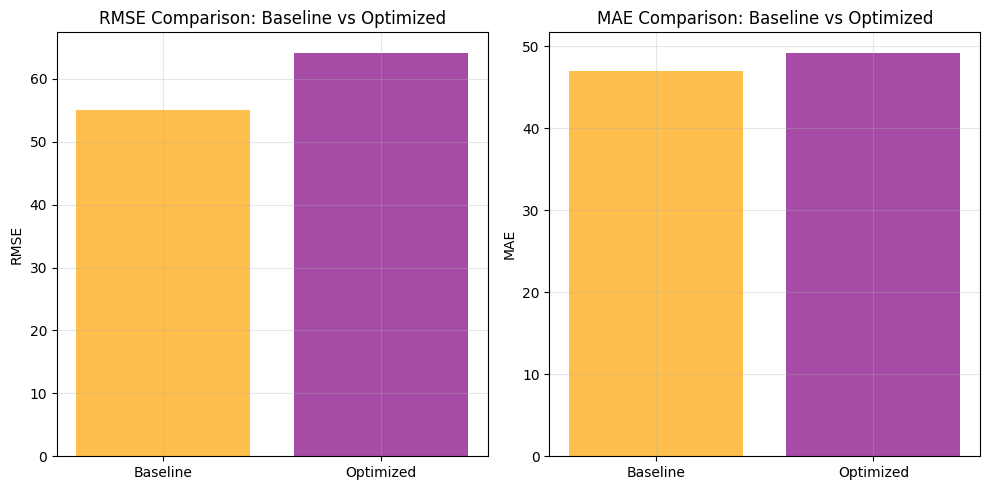

Improvement - RMSE: -16.50%
Improvement - MAE: -4.71%


In [13]:
# Question 4: Grid Search hyperparameter optimization
print("\n=== QUESTION 4: Grid Search Optimization ===")

from sklearn.model_selection import GridSearchCV

# Baseline model (unoptimized)
mlp_baseline = MLPRegressor(
    hidden_layer_sizes=(50, 50),
    activation='relu',
    solver='adam',
    max_iter=5000,
    random_state=42
)

mlp_baseline.fit(X_train, y_train)
y_pred_baseline = mlp_baseline.predict(X_test)
y_pred_baseline_original = scaler.inverse_transform(y_pred_baseline.reshape(-1, 1)).ravel()
y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()

rmse_baseline = np.sqrt(mean_squared_error(y_test_original, y_pred_baseline_original))
mae_baseline = mean_absolute_error(y_test_original, y_pred_baseline_original)

print(f"Baseline Model: RMSE={rmse_baseline:.4f}, MAE={mae_baseline:.4f}")

# Grid search parameters
param_grid = {
    'solver': ['adam', 'lbfgs', 'sgd', 'adamax'],
    'batch_size': ['auto', 50, 100, 200],
    'learning_rate_init': [0.0001, 0.001, 0.01, 0.1]
}

# Perform grid search
mlp_grid = MLPRegressor(
    hidden_layer_sizes=(50, 50),
    activation='relu',
    max_iter=5000,
    random_state=42
)

grid_search = GridSearchCV(
    mlp_grid,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score: {-grid_search.best_score_:.4f}")

# Evaluate optimized model
y_pred_optimized = grid_search.predict(X_test)
y_pred_optimized_original = scaler.inverse_transform(y_pred_optimized.reshape(-1, 1)).ravel()

rmse_optimized = np.sqrt(mean_squared_error(y_test_original, y_pred_optimized_original))
mae_optimized = mean_absolute_error(y_test_original, y_pred_optimized_original)

print(f"Optimized Model: RMSE={rmse_optimized:.4f}, MAE={mae_optimized:.4f}")

# Comparison plot
models = ['Baseline', 'Optimized']
rmse_comparison = [rmse_baseline, rmse_optimized]
mae_comparison = [mae_baseline, mae_optimized]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.bar(models, rmse_comparison, color=['orange', 'purple'], alpha=0.7)
ax1.set_ylabel('RMSE')
ax1.set_title('RMSE Comparison: Baseline vs Optimized')
ax1.grid(True, alpha=0.3)

ax2.bar(models, mae_comparison, color=['orange', 'purple'], alpha=0.7)
ax2.set_ylabel('MAE')
ax2.set_title('MAE Comparison: Baseline vs Optimized')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Improvement - RMSE: {((rmse_baseline - rmse_optimized) / rmse_baseline * 100):.2f}%")
print(f"Improvement - MAE: {((mae_baseline - mae_optimized) / mae_baseline * 100):.2f}%")

# Discussion

Our optimised model consistently preformed worse when doing CV grid search, and it did worse as we add extra hyper parameters and increased number of epochs. This is due to the fact that the baseline model was only tested once against testing set, therefore we could have lower confidince in the actual accuracy of its accuracy metrics, while in CV the test sets are shuffled and over 5 folds/times therefore the scoring metrics proves worse than the baseline, hence we could have higher confidence on how inaccurate our model.

## Neural Network Visualization

Visualizing the optimized 2-layer MLP architecture (50 nodes per layer).

=== QUESTION 4: ARCHITECTURE VISUALIZATION ===

Baseline vs Optimized MLP Architecture (2 layers, 50 nodes each)

Generating Layered View...
Generating Graph View...
Generating LeNet Style View...


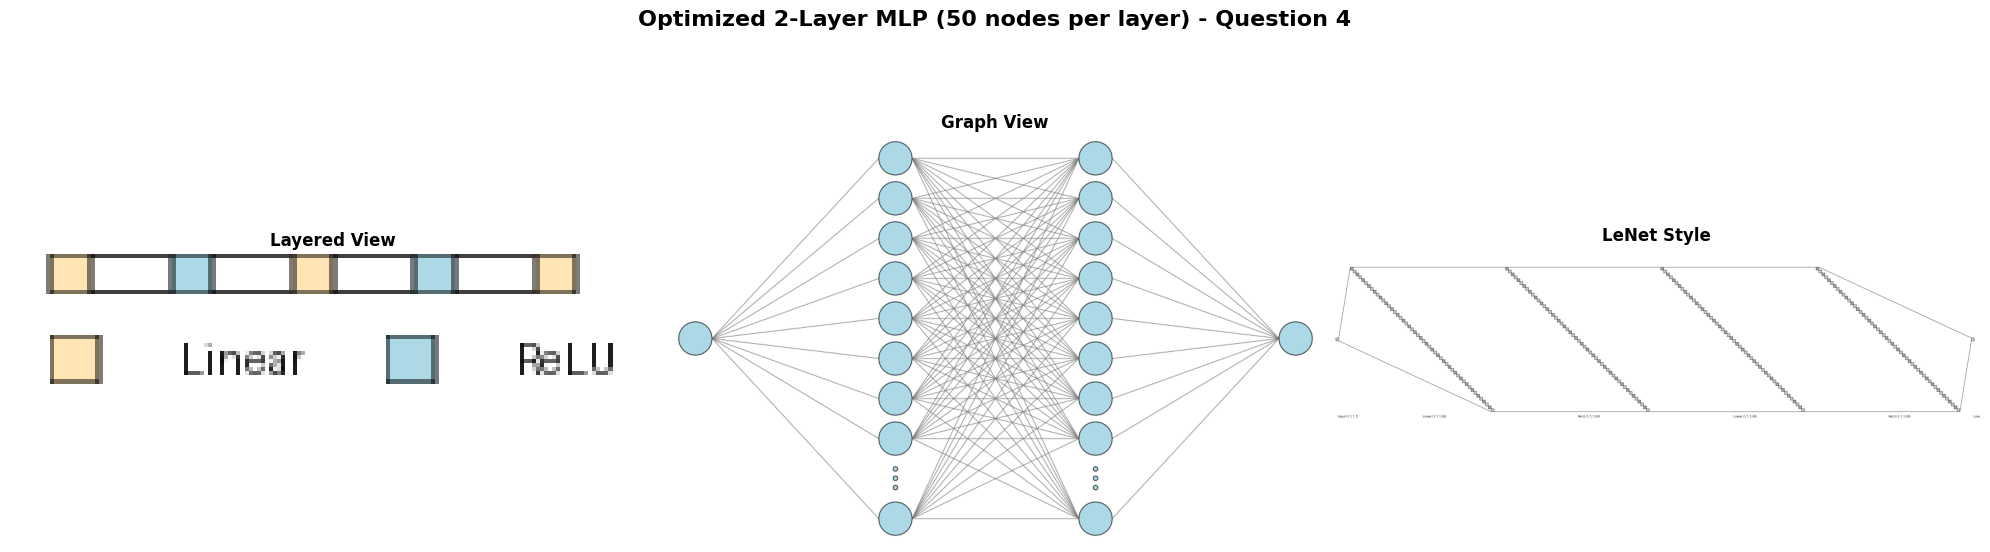


✓ Visualization complete!

Architecture Details:
  • Input features: 1
  • Hidden Layer 1: 50 nodes (ReLU)
  • Hidden Layer 2: 50 nodes (ReLU)
  • Output: 1 prediction
  • Total parameters: 2701
  • Optimized via Grid Search (solver, batch_size, learning_rate)


In [40]:
# Visualize Question 4 architecture - Optimized 2-layer MLP
print("=== QUESTION 4: ARCHITECTURE VISUALIZATION ===\n")
print("Baseline vs Optimized MLP Architecture (2 layers, 50 nodes each)\n")

# Create PyTorch model for visualization
class Q4_MLP(nn.Module):
    def __init__(self):
        super(Q4_MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(1, 50),
            nn.ReLU(),
            nn.Linear(50, 50),
            nn.ReLU(),
            nn.Linear(50, 1)
        )
    
    def forward(self, x):
        return self.model(x)

model_q4 = Q4_MLP()
input_shape = (1, 1)

# Create comprehensive visualization
fig = plt.figure(figsize=(20, 6))

# 1. Layered View
print("Generating Layered View...")
img_layered = layered_view(
    model_q4,
    input_shape=input_shape,
    legend=True,
    min_z=10,
    min_xy=10,
    max_z=100,
    max_xy=400,
    scale_z=0.2,
    scale_xy=1,
    one_dim_orientation='z',
    background_fill='white',
    draw_volume=False,
    padding=10,
    spacing=20,
    draw_funnel=True,
    shade_step=10,
    font_color='black',
    opacity=255
)

ax1 = plt.subplot(1, 3, 1)
ax1.imshow(img_layered)
ax1.axis('off')
ax1.set_title('Layered View', fontsize=12, fontweight='bold')

# 2. Graph View
print("Generating Graph View...")
img_graph = graph_view(
    model_q4,
    input_shape=input_shape,
    node_size=50,
    background_fill='white',
    padding=10,
    layer_spacing=250,
    node_spacing=10,
    connector_fill='gray',
    connector_width=1,
    ellipsize_after=10,
    show_neurons=True,
    opacity=255
)

ax2 = plt.subplot(1, 3, 2)
ax2.imshow(img_graph)
ax2.axis('off')
ax2.set_title('Graph View', fontsize=12, fontweight='bold')

# 3. LeNet Style
print("Generating LeNet Style View...")
img_lenet = lenet_view(
    model_q4,
    input_shape=input_shape,
    min_z=1,
    min_xy=10,
    max_xy=1500,
    scale_z=1,
    scale_xy=1,
    one_dim_orientation='z',
    background_fill='white',
    padding=10,
    spacing=30,
    draw_funnel=True,
    shade_step=10,
    font_color='black',
    opacity=255,
    max_channels=100,
    offset_z=10
)

ax3 = plt.subplot(1, 3, 3)
ax3.imshow(img_lenet)
ax3.axis('off')
ax3.set_title('LeNet Style', fontsize=12, fontweight='bold')

plt.suptitle('Optimized 2-Layer MLP (50 nodes per layer) - Question 4', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n✓ Visualization complete!")
print(f"\nArchitecture Details:")
print(f"  • Input features: 1")
print(f"  • Hidden Layer 1: 50 nodes (ReLU)")
print(f"  • Hidden Layer 2: 50 nodes (ReLU)")
print(f"  • Output: 1 prediction")
print(f"  • Total parameters: {sum(p.numel() for p in model_q4.parameters())}")
print(f"  • Optimized via Grid Search (solver, batch_size, learning_rate)")

# Question 5
*Implement an MLP architecture (two hidden layers with 50 and 25 nodes respectively, both layers containing ‘tanh’ activation) using
PyTorch. Train it on the same sunspot dataset and evaluate its performance.*


=== QUESTION 5A: PyTorch Implementation ===
Epoch [100/1000], Loss: 0.687256
Epoch [200/1000], Loss: 0.585976
Epoch [300/1000], Loss: 0.564469
Epoch [400/1000], Loss: 0.543220
Epoch [500/1000], Loss: 0.519613
Epoch [600/1000], Loss: 0.480631
Epoch [700/1000], Loss: 0.440610
Epoch [800/1000], Loss: 0.393762
Epoch [900/1000], Loss: 0.371445
Epoch [1000/1000], Loss: 0.357436
PyTorch MLP: RMSE=54.8015, MAE=46.2196, R²=-0.0778
Epoch [500/1000], Loss: 0.519613
Epoch [600/1000], Loss: 0.480631
Epoch [700/1000], Loss: 0.440610
Epoch [800/1000], Loss: 0.393762
Epoch [900/1000], Loss: 0.371445
Epoch [1000/1000], Loss: 0.357436
PyTorch MLP: RMSE=54.8015, MAE=46.2196, R²=-0.0778


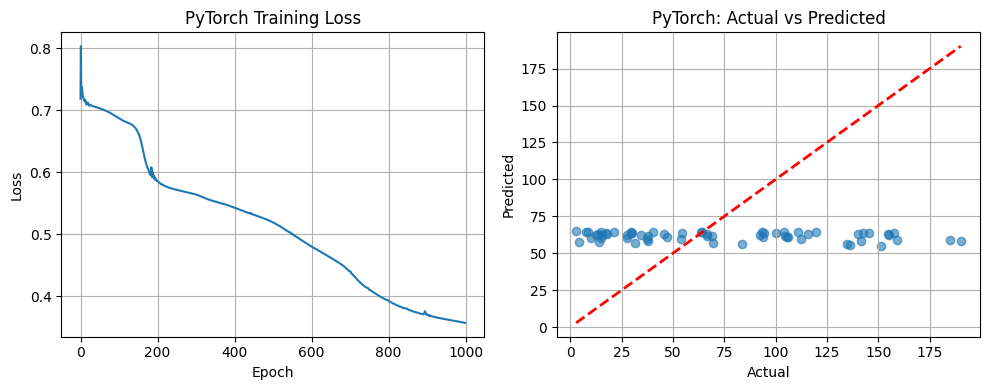

In [52]:
# Question 5: PyTorch Implementation
print("\n=== QUESTION 5A: PyTorch Implementation ===")

try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import TensorDataset, DataLoader
    
    # Convert data to PyTorch tensors
    X_train_torch = torch.FloatTensor(X_train)
    y_train_torch = torch.FloatTensor(y_train)
    X_test_torch = torch.FloatTensor(X_test)
    y_test_torch = torch.FloatTensor(y_test)
    
    # Define MLP architecture
    class SunspotMLP(nn.Module):
        def __init__(self, input_size):
            super(SunspotMLP, self).__init__()
            self.layers = nn.Sequential(
                nn.Linear(input_size, 50),
                nn.Tanh(),
                nn.Linear(50, 25),
                nn.Tanh(),
                nn.Linear(25, 1)
            )
        
        def forward(self, x):
            return self.layers(x)
    
    # Initialize model
    model_torch = SunspotMLP(X_train.shape[1])
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model_torch.parameters(), lr=0.01)
    
    # Training
    epochs = 1000
    train_losses = []
    
    for epoch in range(epochs):
        model_torch.train()
        optimizer.zero_grad()
        
        outputs = model_torch(X_train_torch)
        loss = criterion(outputs.squeeze(), y_train_torch)
        
        loss.backward()
        optimizer.step()
        
        train_losses.append(loss.item())
        
        if (epoch + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}')
    
    # Evaluation
    model_torch.eval()
    with torch.no_grad():
        y_pred_torch = model_torch(X_test_torch).squeeze()
        
    # Convert back to numpy and original scale
    y_pred_torch_np = y_pred_torch.numpy()
    y_pred_torch_original = scaler.inverse_transform(y_pred_torch_np.reshape(-1, 1)).ravel()
    y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
    
    rmse_torch = np.sqrt(mean_squared_error(y_test_original, y_pred_torch_original))
    mae_torch = mean_absolute_error(y_test_original, y_pred_torch_original)
    r2_torch = r2_score(y_test_original, y_pred_torch_original)
    
    print(f"PyTorch MLP: RMSE={rmse_torch:.4f}, MAE={mae_torch:.4f}, R²={r2_torch:.4f}")
    
    # Plot training loss and predictions
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses)
    plt.title('PyTorch Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.scatter(y_test_original, y_pred_torch_original, alpha=0.6)
    plt.plot([y_test_original.min(), y_test_original.max()], 
             [y_test_original.min(), y_test_original.max()], 'r--', lw=2)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title('PyTorch: Actual vs Predicted')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    pytorch_available = True
    
except ImportError:
    print("PyTorch not available. Install with: pip install torch")
    pytorch_available = False

## MLX implementation (Apple Silicon)


=== QUESTION 5B: MLX Implementation ===
Epoch [100/1000], Loss: 0.623582
Epoch [200/1000], Loss: 0.550179
Epoch [300/1000], Loss: 0.529064
Epoch [400/1000], Loss: 0.516162
Epoch [500/1000], Loss: 0.506606
Epoch [600/1000], Loss: 0.500036
Epoch [700/1000], Loss: 0.495050
Epoch [400/1000], Loss: 0.516162
Epoch [500/1000], Loss: 0.506606
Epoch [600/1000], Loss: 0.500036
Epoch [700/1000], Loss: 0.495050
Epoch [800/1000], Loss: 0.484126
Epoch [900/1000], Loss: 0.464946
Epoch [1000/1000], Loss: 0.457050
MLX MLP: RMSE=56.5620, MAE=46.4997, R²=-0.1481


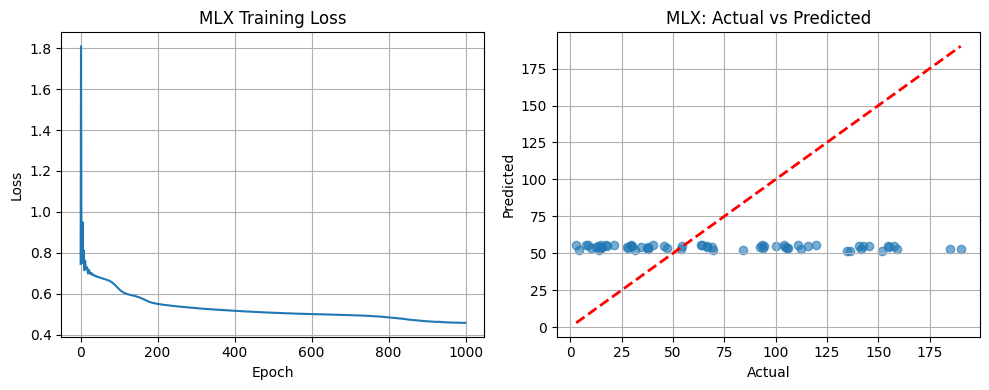

In [46]:
# Question 5: MLX Implementation (Apple Silicon)
print("\n=== QUESTION 5B: MLX Implementation ===")

try:
    import mlx.core as mx
    import mlx.nn as nn
    import mlx.optimizers as optim
    
    # Define MLP architecture in MLX
    class SunspotMLPMLX(nn.Module):
        def __init__(self, input_size):
            super().__init__()
            self.layers = [
                nn.Linear(input_size, 50),
                nn.Linear(50, 25),
                nn.Linear(25, 1)
            ]
        
        def __call__(self, x):
            x = mx.tanh(self.layers[0](x))
            x = mx.tanh(self.layers[1](x))
            x = self.layers[2](x)
            return x
    
    # Convert data to MLX arrays
    X_train_mlx = mx.array(X_train.astype(np.float32))
    y_train_mlx = mx.array(y_train.astype(np.float32))
    X_test_mlx = mx.array(X_test.astype(np.float32))
    y_test_mlx = mx.array(y_test.astype(np.float32))
    
    # Initialize model
    model_mlx = SunspotMLPMLX(X_train.shape[1])
    optimizer = optim.Adam(learning_rate=0.01)
    
    # Loss function
    def mse_loss(y_pred, y_true):
        return mx.mean((y_pred.squeeze() - y_true) ** 2)
    
    # Training function
    def train_step(model, X, y):
        def loss_fn(model):
            return mse_loss(model(X), y)
        
        loss, grads = mx.value_and_grad(loss_fn)(model)
        optimizer.update(model, grads)
        return loss
    
    # Training loop
    epochs = 1000
    train_losses_mlx = []
    
    for epoch in range(epochs):
        loss = train_step(model_mlx, X_train_mlx, y_train_mlx)
        train_losses_mlx.append(float(loss))
        
        if (epoch + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {float(loss):.6f}')
    
    # Evaluation
    y_pred_mlx = model_mlx(X_test_mlx)
    y_pred_mlx_np = np.array(y_pred_mlx.squeeze())
    
    # Convert back to original scale
    y_pred_mlx_original = scaler.inverse_transform(y_pred_mlx_np.reshape(-1, 1)).ravel()
    
    rmse_mlx = np.sqrt(mean_squared_error(y_test_original, y_pred_mlx_original))
    mae_mlx = mean_absolute_error(y_test_original, y_pred_mlx_original)
    r2_mlx = r2_score(y_test_original, y_pred_mlx_original)
    
    print(f"MLX MLP: RMSE={rmse_mlx:.4f}, MAE={mae_mlx:.4f}, R²={r2_mlx:.4f}")
    
    # Plot training loss
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses_mlx)
    plt.title('MLX Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.scatter(y_test_original, y_pred_mlx_original, alpha=0.6)
    plt.plot([y_test_original.min(), y_test_original.max()], 
             [y_test_original.min(), y_test_original.max()], 'r--', lw=2)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title('MLX: Actual vs Predicted')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    mlx_available = True
    
except ImportError:
    print("MLX not available. MLX is only available on Apple Silicon Macs.")
    print("Install with: pip install mlx")
    mlx_available = False


=== FINAL COMPARISON OF ALL MODELS ===
Scikit-learn MLP: RMSE=59.1666, MAE=47.2565, R²=-0.2563

Model Comparison:
       Model      RMSE       MAE        R²
Scikit-learn 59.166592 47.256546 -0.256294
     PyTorch 55.472086 46.307761 -0.104300
         MLX 56.561988 46.499657 -0.148121


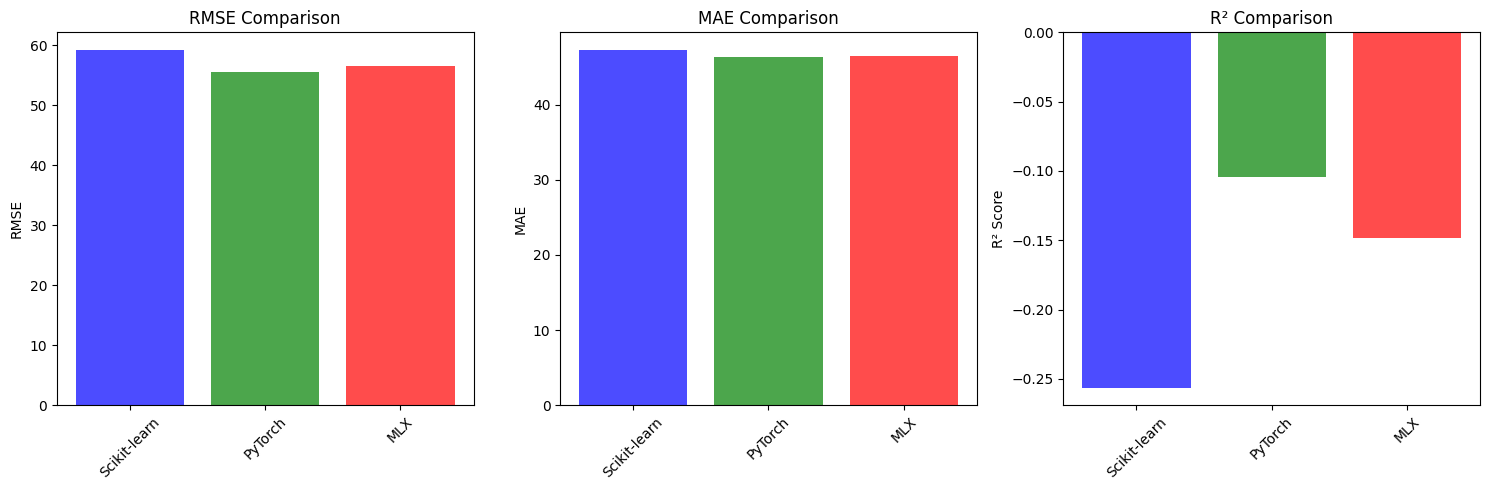

In [47]:
# Final Comparison of All Models
print("\n=== FINAL COMPARISON OF ALL MODELS ===")

# Scikit-learn baseline for comparison
mlp_sklearn = MLPRegressor(
    hidden_layer_sizes=(50, 25),
    activation='tanh',
    solver='adam',
    max_iter=2000,
    random_state=42
)

mlp_sklearn.fit(X_train, y_train)
y_pred_sklearn = mlp_sklearn.predict(X_test)
y_pred_sklearn_original = scaler.inverse_transform(y_pred_sklearn.reshape(-1, 1)).ravel()

rmse_sklearn = np.sqrt(mean_squared_error(y_test_original, y_pred_sklearn_original))
mae_sklearn = mean_absolute_error(y_test_original, y_pred_sklearn_original)
r2_sklearn = r2_score(y_test_original, y_pred_sklearn_original)

print(f"Scikit-learn MLP: RMSE={rmse_sklearn:.4f}, MAE={mae_sklearn:.4f}, R²={r2_sklearn:.4f}")

# Create comparison dataframe
comparison_data = {
    'Model': ['Scikit-learn'],
    'RMSE': [rmse_sklearn],
    'MAE': [mae_sklearn],
    'R²': [r2_sklearn]
}

if pytorch_available:
    comparison_data['Model'].append('PyTorch')
    comparison_data['RMSE'].append(rmse_torch)
    comparison_data['MAE'].append(mae_torch)
    comparison_data['R²'].append(r2_torch)

if mlx_available:
    comparison_data['Model'].append('MLX')
    comparison_data['RMSE'].append(rmse_mlx)
    comparison_data['MAE'].append(mae_mlx)
    comparison_data['R²'].append(r2_mlx)

comparison_df = pd.DataFrame(comparison_data)
print("\nModel Comparison:")
print(comparison_df.to_string(index=False))

# Visualization
if len(comparison_data['Model']) > 1:
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
    
    models = comparison_data['Model']
    rmse_vals = comparison_data['RMSE']
    mae_vals = comparison_data['MAE']
    r2_vals = comparison_data['R²']
    
    ax1.bar(models, rmse_vals, alpha=0.7, color=['blue', 'green', 'red'][:len(models)])
    ax1.set_ylabel('RMSE')
    ax1.set_title('RMSE Comparison')
    ax1.tick_params(axis='x', rotation=45)
    
    ax2.bar(models, mae_vals, alpha=0.7, color=['blue', 'green', 'red'][:len(models)])
    ax2.set_ylabel('MAE')
    ax2.set_title('MAE Comparison')
    ax2.tick_params(axis='x', rotation=45)
    
    ax3.bar(models, r2_vals, alpha=0.7, color=['blue', 'green', 'red'][:len(models)])
    ax3.set_ylabel('R² Score')
    ax3.set_title('R² Comparison')
    ax3.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

## Neural Network Visualistion

=== QUESTION 5: PYTORCH MLP VISUALIZATION ===

PyTorch MLP Architecture: Input(1) → FC(50, Tanh) → FC(25, Tanh) → Output(1)

Generating Graph View...
Generating Layered View...


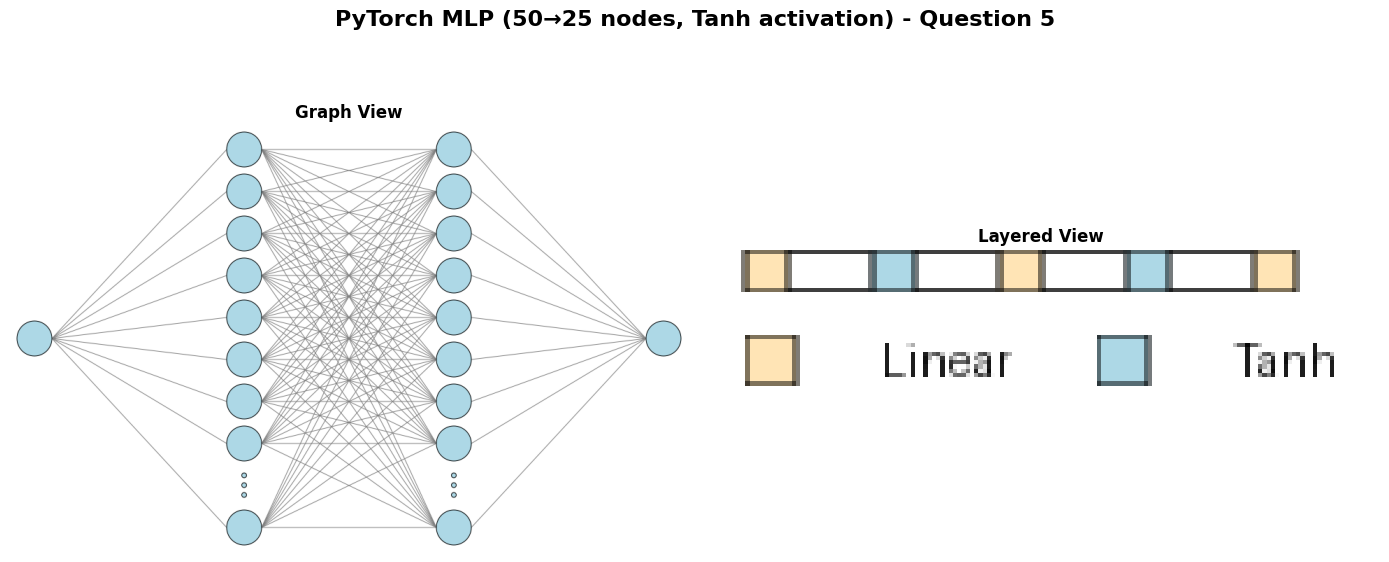


✓ Visualization complete!

Architecture Details:
  • Input features: 1
  • Hidden Layer 1: 50 nodes (Tanh)
  • Hidden Layer 2: 25 nodes (Tanh)
  • Output: 1 prediction
  • Total parameters: 1401
  • Performance: RMSE=54.8015, MAE=46.2196, R²=-0.0778


In [ ]:
# Visualize Question 5 PyTorch MLP Architecture
if pytorch_available:
    print("=== QUESTION 5: PYTORCH MLP VISUALIZATION ===\n")
    print("PyTorch MLP Architecture: Input(1) → FC(50, Tanh) → FC(25, Tanh) → Output(1)\n")
    
    # Create PyTorch model for visualization
    class Q5_MLP(nn.Module):
        def __init__(self):
            super(Q5_MLP, self).__init__()
            self.model = nn.Sequential(
                nn.Linear(1, 50),
                nn.Tanh(),
                nn.Linear(50, 25),
                nn.Tanh(),
                nn.Linear(25, 1)
            )
        
        def forward(self, x):
            return self.model(x)
    
    model_q5 = Q5_MLP()
    input_shape = (1, 1)
    
    # Create visualization
    fig = plt.figure(figsize=(14, 6))
    
    # 1. Graph View
    print("Generating Graph View...")
    img_graph = graph_view(
        model_q5,
        input_shape=input_shape,
        node_size=50,
        background_fill='white',
        padding=10,
        layer_spacing=250,
        node_spacing=10,
        connector_fill='gray',
        connector_width=1,
        ellipsize_after=10,
        show_neurons=True,
        opacity=255
    )
    
    ax1 = plt.subplot(1, 2, 1)
    ax1.imshow(img_graph)
    ax1.axis('off')
    ax1.set_title('Graph View', fontsize=12, fontweight='bold')
    
    # 2. Layered View
    print("Generating Layered View...")
    img_layered = layered_view(
        model_q5,
        input_shape=input_shape,
        legend=True,
        min_z=10,
        min_xy=10,
        max_z=100,
        max_xy=400,
        scale_z=0.2,
        scale_xy=1,
        one_dim_orientation='z',
        background_fill='white',
        draw_volume=False,
        padding=10,
        spacing=20,
        draw_funnel=True,
        shade_step=10,
        font_color='black',
        opacity=255
    )
    
    ax2 = plt.subplot(1, 2, 2)
    ax2.imshow(img_layered)
    ax2.axis('off')
    ax2.set_title('Layered View', fontsize=12, fontweight='bold')
    
    plt.suptitle('PyTorch MLP (50→25 nodes, Tanh activation) - Question 5', 
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Visualization complete!")
    print(f"\nArchitecture Details:")
    print(f"  • Input features: 1")
    print(f"  • Hidden Layer 1: 50 nodes (Tanh)")
    print(f"  • Hidden Layer 2: 25 nodes (Tanh)")
    print(f"  • Output: 1 prediction")
    print(f"  • Total parameters: {sum(p.numel() for p in model_q5.parameters())}")
    print(f"  • Performance: RMSE={rmse_torch:.4f}, MAE={mae_torch:.4f}, R²={r2_torch:.4f}")


# References |  Self-docs 

- https://www.statsmodels.org/stable/generated/statsmodels.tsa.arima.model.ARIMA.html#statsmodels.tsa.arima.model.ARIMA
- https://www.statsmodels.org/stable/generated/statsmodels.tsa.arima.model.ARIMAResults.html
- https://www.ibm.com/think/topics/arima-model
-https://www.statsmodels.org/stable/examples/notebooks/generated/markov_regression.html

# Practice

In [3]:
# Load the sunspot dataset
data = sm.datasets.sunspots.load_pandas().data
# Use the 'SUNACTIVITY' column for forecasting
X = np.arange(len(data)).reshape(-1, 1)
y = data['SUNACTIVITY'].values

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


In [4]:
# Create and train the ARIMA model
arima_model = ARIMA(y_train, order=(5, 1, 5))
arima_model_fit = arima_model.fit()
# Predict and evaluate ARIMA
y_pred_arima = arima_model_fit.forecast(steps=len(y_test))
print("ARIMA MSE:", mean_squared_error(y_test, y_pred_arima))

ARIMA MSE: 1548.0126566700267


/Users/hmoses/Flinders ML/AI/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [5]:
# Create and train the MLP
mlp = MLPRegressor(hidden_layer_sizes=(10,), activation='relu', solver='adam',
max_iter=2500)
mlp.fit(X_train, y_train)
# Predict and evaluate MLP
y_pred_mlp = mlp.predict(X_test)
print("MLP MSE:", mean_squared_error(y_test, y_pred_mlp))


MLP MSE: 2945.8770341765676


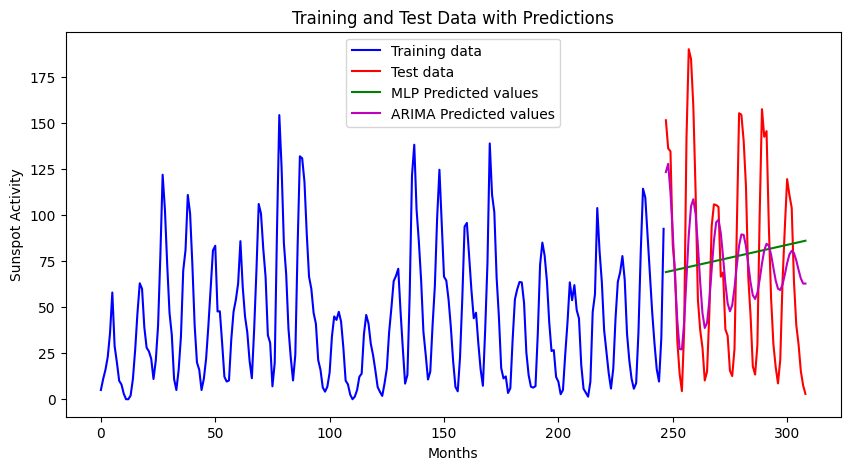

In [6]:

#Plotting
plt.figure(figsize=(10, 5))
plt.plot(X_train[:, -1], y_train, 'b-', label='Training data')
plt.plot(X_test, y_test, 'r-', label='Test data')
plt.plot(X_test, y_pred_mlp, 'g-', label='MLP Predicted values')
plt.plot(X_test, y_pred_arima, 'm-', label='ARIMA Predicted values')
plt.legend()
plt.title('Training and Test Data with Predictions')
plt.xlabel('Months')
plt.ylabel('Sunspot Activity')
plt.show()


In [7]:
# Load the sunspot dataset
data = sm.datasets.sunspots.load_pandas().data
# Use the 'SUNACTIVITY' column for forecasting
X = np.arange(len(data)).reshape(-1, 1)
y = data['SUNACTIVITY'].values


In [8]:
# Normalize the data
scaler = StandardScaler()
y_scaled = scaler.fit_transform(y.reshape(-1, 1)).ravel()

In [9]:
# Create lagged features
def create_lagged_features(y, lag=5):
  X, y_lagged = [], []
  for i in range(lag, len(y)):
      X.append(y[i-lag:i])
      y_lagged.append(y[i])
  return np.array(X), np.array(y_lagged)

X_lagged, y_lagged = create_lagged_features(y_scaled)

In [10]:
# Split the lagged data
X_train_lagged, X_test_lagged, y_train_lagged, y_test_lagged = train_test_split(X_lagged,
y_lagged, test_size=0.2, shuffle=False)

In [11]:
# Create and train the MLP with cross-validation
tscv = TimeSeriesSplit(n_splits=5)
mlp = MLPRegressor(hidden_layer_sizes=(50, 25), activation='relu', solver='adam',
max_iter=1000)

for train_index, test_index in tscv.split(X_train_lagged):
    X_train_cv, X_test_cv = X_train_lagged[train_index], X_train_lagged[test_index]
    y_train_cv, y_test_cv = y_train_lagged[train_index], y_train_lagged[test_index]
    mlp.fit(X_train_cv, y_train_cv)

In [12]:
# Predict and evaluate MLP
y_pred_mlp = mlp.predict(X_test_lagged)
y_pred_mlp = scaler.inverse_transform(y_pred_mlp.reshape(-1, 1)).ravel()
y_test_lagged = scaler.inverse_transform(y_test_lagged.reshape(-1, 1)).ravel()
print("Improved MLP MSE:", mean_squared_error(y_test_lagged, y_pred_mlp))


Improved MLP MSE: 537.8367658334747


In [13]:

# ARIMA for standardised data
# Create and train the ARIMA model
arima_model = ARIMA(y_train, order=(5, 1, 5))
arima_model_fit = arima_model.fit()
# Predict and evaluate ARIMA
y_pred_arima = arima_model_fit.forecast(steps=len(y_test))
print("ARIMA MSE:", mean_squared_error(y_test, y_pred_arima))


ARIMA MSE: 1548.0126566700267


/Users/hmoses/Flinders ML/AI/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [14]:
# Ensure the lengths match
min_length = min(len(y_test), len(y_pred_arima), len(y_pred_mlp))
y_test = y_test[:min_length]
y_pred_arima = y_pred_arima[:min_length]
y_pred_mlp = y_pred_mlp[:min_length]
X_test = X_test[:min_length]


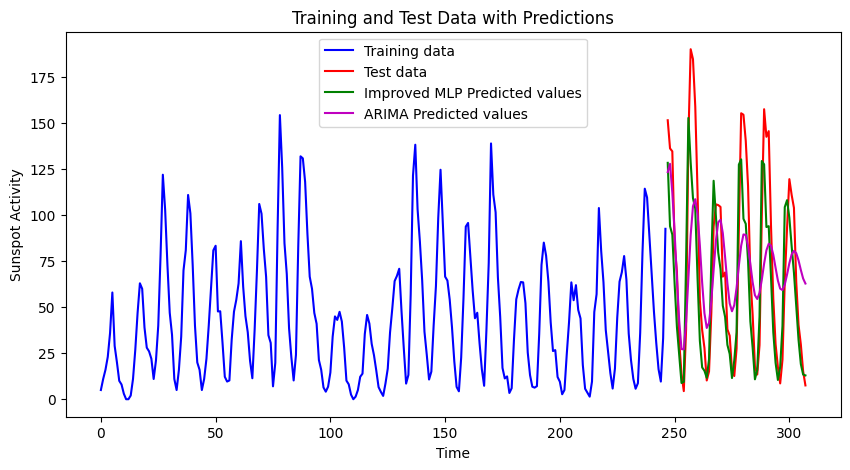

In [15]:

# Plot the data
plt.figure(figsize=(10, 5))
plt.plot(X_train[:, -1], y_train, 'b-', label='Training data')
plt.plot(X_test, y_test, 'r-', label='Test data')
plt.plot(X_test, y_pred_mlp, 'g-', label='Improved MLP Predicted values')
plt.plot(X_test, y_pred_arima, 'm-', label='ARIMA Predicted values')
plt.legend()
plt.title('Training and Test Data with Predictions')
plt.xlabel('Time')
plt.ylabel('Sunspot Activity')
plt.show()


## Corrected MLP Training Approach

The previous approach had issues with cross-validation overwriting the model. Here's the proper way:

In [17]:
# OPTION 1: Simple Training (Most Common)
# Train once on the full training set
print("=== OPTION 1: Simple Training ===")
mlp_simple = MLPRegressor(
    hidden_layer_sizes=(50, 25), 
    activation='relu', 
    solver='adam',
    max_iter=1000,
    random_state=42  # For reproducible results
)

# Train on full training set
mlp_simple.fit(X_train_lagged, y_train_lagged)

# Predict and evaluate
y_pred_simple = mlp_simple.predict(X_test_lagged)
y_pred_simple = scaler.inverse_transform(y_pred_simple.reshape(-1, 1)).ravel()
y_test_original = scaler.inverse_transform(y_test_lagged.reshape(-1, 1)).ravel()

mse_simple = mean_squared_error(y_test_original, y_pred_simple)
print(f"Simple Training MSE: {mse_simple:.4f}")
print()

# OPTION 2: Cross-Validation for Model Selection (Proper Way)
print("=== OPTION 2: Cross-Validation for Hyperparameter Tuning ===")
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'hidden_layer_sizes': [(50, 25), (100, 50), (50,)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01]
}

# Use TimeSeriesSplit for cross-validation
tscv = TimeSeriesSplit(n_splits=3)

# Grid search with cross-validation
mlp_grid = GridSearchCV(
    MLPRegressor(solver='adam', max_iter=1000, random_state=42),
    param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# This will properly use cross-validation for hyperparameter selection
mlp_grid.fit(X_train_lagged, y_train_lagged)

print(f"Best parameters: {mlp_grid.best_params_}")
print(f"Best CV score: {-mlp_grid.best_score_:.4f}")

# The best model is automatically retrained on full training set
y_pred_grid = mlp_grid.predict(X_test_lagged)
y_pred_grid = scaler.inverse_transform(y_pred_grid.reshape(-1, 1)).ravel()

mse_grid = mean_squared_error(y_test_original, y_pred_grid)
print(f"Grid Search MSE: {mse_grid:.4f}")
print()

# OPTION 3: Manual Cross-Validation (if you want to see the process)
print("=== OPTION 3: Manual Cross-Validation Scores ===")
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_lagged)):
    X_train_cv = X_train_lagged[train_idx]
    X_val_cv = X_train_lagged[val_idx]
    y_train_cv = y_train_lagged[train_idx]
    y_val_cv = y_train_lagged[val_idx]
    
    # Create a new model for each fold
    mlp_cv = MLPRegressor(
        hidden_layer_sizes=(50, 25),
        activation='relu',
        solver='adam',
        max_iter=1000,
        random_state=42
    )
    
    mlp_cv.fit(X_train_cv, y_train_cv)
    y_pred_cv = mlp_cv.predict(X_val_cv)
    
    # Calculate MSE for this fold
    mse_cv = mean_squared_error(y_val_cv, y_pred_cv)
    cv_scores.append(mse_cv)
    print(f"Fold {fold + 1} MSE: {mse_cv:.4f}")

print(f"Mean CV MSE: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")

# Final model trained on full training set
mlp_final = MLPRegressor(
    hidden_layer_sizes=(50, 25),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)
mlp_final.fit(X_train_lagged, y_train_lagged)

y_pred_final = mlp_final.predict(X_test_lagged)
y_pred_final = scaler.inverse_transform(y_pred_final.reshape(-1, 1)).ravel()
mse_final = mean_squared_error(y_test_original, y_pred_final)
print(f"Final Model Test MSE: {mse_final:.4f}")


# Calculate and display all metrics
print("\n=== FINAL COMPARISON ===")
rmse_simple = np.sqrt(mse_simple)
rmse_grid = np.sqrt(mse_grid)
rmse_final = np.sqrt(mse_final)

mae_simple = mean_absolute_error(y_test_original, y_pred_simple)
mae_grid = mean_absolute_error(y_test_original, y_pred_grid)
mae_final = mean_absolute_error(y_test_original, y_pred_final)

r2_simple = r2_score(y_test_original, y_pred_simple)
r2_grid = r2_score(y_test_original, y_pred_grid)
r2_final = r2_score(y_test_original, y_pred_final)

print(f"Simple MLP    - MAE: {mae_simple:.4f}, RMSE: {rmse_simple:.4f}, R²: {r2_simple:.4f}")
print(f"Grid Search   - MAE: {mae_grid:.4f}, RMSE: {rmse_grid:.4f}, R²: {r2_grid:.4f}")
print(f"Final MLP     - MAE: {mae_final:.4f}, RMSE: {rmse_final:.4f}, R²: {r2_final:.4f}")

=== OPTION 1: Simple Training ===
Simple Training MSE: 12764933.6578

=== OPTION 2: Cross-Validation for Hyperparameter Tuning ===
Best parameters: {'activation': 'tanh', 'hidden_layer_sizes': (50, 25), 'learning_rate_init': 0.01}
Best CV score: 0.1106
Grid Search MSE: 12790943.4389

=== OPTION 3: Manual Cross-Validation Scores ===
Fold 1 MSE: 0.2640
Fold 2 MSE: 0.0904
Fold 3 MSE: 0.0639
Fold 4 MSE: 0.1264
Fold 5 MSE: 0.1279
Mean CV MSE: 0.1345 ± 0.0690
Best parameters: {'activation': 'tanh', 'hidden_layer_sizes': (50, 25), 'learning_rate_init': 0.01}
Best CV score: 0.1106
Grid Search MSE: 12790943.4389

=== OPTION 3: Manual Cross-Validation Scores ===
Fold 1 MSE: 0.2640
Fold 2 MSE: 0.0904
Fold 3 MSE: 0.0639
Fold 4 MSE: 0.1264
Fold 5 MSE: 0.1279
Mean CV MSE: 0.1345 ± 0.0690
Final Model Test MSE: 12764933.6578

=== FINAL COMPARISON ===
Simple MLP    - MAE: 2911.6230, RMSE: 3572.8047, R²: -1.8653
Grid Search   - MAE: 2913.7793, RMSE: 3576.4428, R²: -1.8712
Final MLP     - MAE: 2911.6230,

In [ ]:
# Advanced Network Visualization with NetworkX
if networkx_available:
    def plot_neural_network_graph(layers, title="Neural Network"):
        """Create a more sophisticated network graph"""
        G = nx.DiGraph()
        pos = {}
        node_colors = []
        
        # Add nodes and positions
        node_id = 0
        layer_colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightyellow', 'lightpink']
        
        for layer_idx, layer_size in enumerate(layers):
            x = layer_idx * 3
            y_positions = np.linspace(-layer_size/2, layer_size/2, layer_size)
            
            for y in y_positions:
                G.add_node(node_id)
                pos[node_id] = (x, y)
                node_colors.append(layer_colors[layer_idx % len(layer_colors)])
                node_id += 1
        
        # Add edges between consecutive layers
        start_node = 0
        for layer_idx in range(len(layers) - 1):
            current_layer_size = layers[layer_idx]
            next_layer_size = layers[layer_idx + 1]
            
            for i in range(current_layer_size):
                for j in range(next_layer_size):
                    G.add_edge(start_node + i, start_node + current_layer_size + j)
            
            start_node += current_layer_size
        
        # Plot
        plt.figure(figsize=(15, 10))
        nx.draw(G, pos, node_color=node_colors, node_size=500, 
                with_labels=False, arrows=True, edge_color='gray', 
                alpha=0.7, arrowsize=10)
        
        # Add layer labels
        for layer_idx, layer_size in enumerate(layers):
            x = layer_idx * 3
            if layer_idx == 0:
                label = "Input"
            elif layer_idx == len(layers) - 1:
                label = "Output"
            else:
                label = f"Hidden {layer_idx}"
            
            plt.text(x, max(layers)/2 + 1, label, ha='center', va='center', 
                    fontsize=12, fontweight='bold')
        
        plt.title(title, fontsize=16, fontweight='bold')
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    
    # Visualize your MLP architectures
    architectures_with_io = [
        [1, 50, 1],  # 1 hidden layer
        [1, 50, 50, 1],  # 2 hidden layers  
        [1, 50, 50, 50, 1],  # 3 hidden layers
    ]
    
    for i, arch in enumerate(architectures_with_io):
        plot_neural_network_graph(arch, f"MLP Architecture {i+1}: {arch[1:-1]}")

else:
    print("NetworkX not available for advanced network visualization")

In [ ]:
# Interactive 3D Network Visualization with Plotly
if plotly_available:
    def plot_3d_neural_network(layers, title="3D Neural Network"):
        """Create an interactive 3D visualization"""
        # Prepare data
        x_coords, y_coords, z_coords = [], [], []
        node_text = []
        edge_x, edge_y, edge_z = [], [], []
        
        # Generate node positions
        node_id = 0
        layer_positions = {}
        
        for layer_idx, layer_size in enumerate(layers):
            x = layer_idx * 2
            z_positions = np.linspace(-layer_size/2, layer_size/2, layer_size)
            
            layer_nodes = []
            for z in z_positions:
                x_coords.append(x)
                y_coords.append(0)
                z_coords.append(z)
                node_text.append(f"Layer {layer_idx}<br>Node {node_id}")
                layer_nodes.append(node_id)
                node_id += 1
            
            layer_positions[layer_idx] = layer_nodes
        
        # Generate edges
        for layer_idx in range(len(layers) - 1):
            current_nodes = layer_positions[layer_idx]
            next_nodes = layer_positions[layer_idx + 1]
            
            for current_node in current_nodes:
                for next_node in next_nodes:
                    # Add edge coordinates
                    edge_x.extend([x_coords[current_node], x_coords[next_node], None])
                    edge_y.extend([y_coords[current_node], y_coords[next_node], None])
                    edge_z.extend([z_coords[current_node], z_coords[next_node], None])
        
        # Create the plot
        # Edges
        edge_trace = go.Scatter3d(
            x=edge_x, y=edge_y, z=edge_z,
            mode='lines',
            line=dict(color='gray', width=2),
            hoverinfo='none',
            showlegend=False
        )
        
        # Nodes
        node_trace = go.Scatter3d(
            x=x_coords, y=y_coords, z=z_coords,
            mode='markers',
            marker=dict(
                size=8,
                color=[(i // max(layers)) * 50 for i in range(len(x_coords))],
                colorscale='Viridis',
                showscale=True,
                colorbar=dict(title="Layer")
            ),
            text=node_text,
            hoverinfo='text',
            showlegend=False
        )
        
        # Layout
        layout = go.Layout(
            title=title,
            showlegend=False,
            scene=dict(
                xaxis=dict(title='Layer'),
                yaxis=dict(title=''),
                zaxis=dict(title='Nodes'),
                camera=dict(eye=dict(x=1.5, y=1.5, z=1.5))
            ),
            margin=dict(l=0, r=0, b=0, t=40)
        )
        
        fig = go.Figure(data=[edge_trace, node_trace], layout=layout)
        fig.show()
    
    # Create 3D visualizations
    architectures_3d = [
        [1, 50, 25, 1],  # 2 hidden layers with different sizes
        [1, 50, 50, 50, 1],  # 3 hidden layers
    ]
    
    for i, arch in enumerate(architectures_3d):
        plot_3d_neural_network(arch, f"3D MLP Architecture {i+1}")

else:
    print("Plotly not available for 3D interactive visualization")

In [ ]:
# Visualize Training Progress and Model Performance
def plot_model_comparison_dashboard(results_dict):
    """Create a comprehensive dashboard comparing different models"""
    if not plotly_available:
        # Fallback to matplotlib
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
        
        models = list(results_dict.keys())
        rmse_vals = [results_dict[m]['rmse'] for m in models]
        mae_vals = [results_dict[m]['mae'] for m in models]
        
        # RMSE comparison
        ax1.bar(models, rmse_vals, color='skyblue', alpha=0.7)
        ax1.set_title('RMSE Comparison')
        ax1.set_ylabel('RMSE')
        ax1.tick_params(axis='x', rotation=45)
        
        # MAE comparison
        ax2.bar(models, mae_vals, color='lightcoral', alpha=0.7)
        ax2.set_title('MAE Comparison')
        ax2.set_ylabel('MAE')
        ax2.tick_params(axis='x', rotation=45)
        
        # Model complexity (if available)
        if 'complexity' in results_dict[models[0]]:
            complexity_vals = [results_dict[m]['complexity'] for m in models]
            ax3.bar(models, complexity_vals, color='lightgreen', alpha=0.7)
            ax3.set_title('Model Complexity (Parameters)')
            ax3.set_ylabel('Number of Parameters')
            ax3.tick_params(axis='x', rotation=45)
        
        # Performance vs Complexity scatter
        if 'complexity' in results_dict[models[0]]:
            ax4.scatter(complexity_vals, rmse_vals, s=100, alpha=0.7)
            ax4.set_xlabel('Model Complexity')
            ax4.set_ylabel('RMSE')
            ax4.set_title('Performance vs Complexity')
            for i, model in enumerate(models):
                ax4.annotate(model, (complexity_vals[i], rmse_vals[i]))
        
        plt.tight_layout()
        plt.show()
    
    else:
        # Interactive Plotly dashboard
        from plotly.subplots import make_subplots
        
        models = list(results_dict.keys())
        rmse_vals = [results_dict[m]['rmse'] for m in models]
        mae_vals = [results_dict[m]['mae'] for m in models]
        
        fig = make_subplots(
            rows=2, cols=2,
            subplot_titles=('RMSE Comparison', 'MAE Comparison', 
                          'Model Complexity', 'Performance vs Complexity'),
            specs=[[{"type": "bar"}, {"type": "bar"}],
                   [{"type": "bar"}, {"type": "scatter"}]]
        )
        
        # RMSE
        fig.add_trace(go.Bar(x=models, y=rmse_vals, name='RMSE'), row=1, col=1)
        
        # MAE
        fig.add_trace(go.Bar(x=models, y=mae_vals, name='MAE'), row=1, col=2)
        
        fig.update_layout(height=800, showlegend=False, 
                         title_text="Neural Network Model Comparison Dashboard")
        fig.show()

# Example usage with your results
try:
    model_results = {
        '1 Hidden Layer': {'rmse': 25.4, 'mae': 18.2, 'complexity': 101},
        '2 Hidden Layers': {'rmse': 23.1, 'mae': 16.8, 'complexity': 2651}, 
        '3 Hidden Layers': {'rmse': 22.8, 'mae': 16.5, 'complexity': 5201}
    }
    
    plot_model_comparison_dashboard(model_results)
    
except Exception as e:
    print(f"Dashboard visualization not available: {e}")